# Consolidated Translation Evaluation

Evaluates round-trip translation quality (EN → X → EN) across six models:
- **Claude-Haiku** (API)
- **Llama-3.2-3B-Instruct** (base)
- **Llama-3.2-3B-FT-WMT** (LoRA fine-tuned on WMT20, Chinese only)
- **Llama-3.2-3B-FT-Tatoeba** (LoRA fine-tuned on Tatoeba, Chinese only)
- **Qwen3-4B-Instruct** (base)
- **Qwen3-4B-FT-Tatoeba** (LoRA fine-tuned on Tatoeba, Chinese only)

Metrics: BLEU, ChrF, BERTScore, BLEURT

In [20]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
!pip install -q sacrebleu bert-score

BLEURT_AVAILABLE = False
try:
    from bleurt import score as bleurt_score
    BLEURT_AVAILABLE = True
except ImportError:
    print("BLEURT not installed. Attempting installation...")
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/google-research/bleurt.git"])
        from bleurt import score as bleurt_score
        BLEURT_AVAILABLE = True
        print("BLEURT installed successfully.")
    except Exception as e:
        print(f"BLEURT installation failed: {e}")
        print("Continuing without BLEURT. Other metrics will still be computed.")

In [22]:
import os
import zipfile
import urllib.request

BLEURT_CHECKPOINT = None
BLEURT_CACHE_DIR = "/content/drive/MyDrive/Coding project/bleurt_checkpoint"
BLEURT_CHECKPOINT_PATH = os.path.join(BLEURT_CACHE_DIR, "BLEURT-20")

if BLEURT_AVAILABLE:
    if os.path.isdir(BLEURT_CHECKPOINT_PATH):
        print(f"BLEURT checkpoint found at {BLEURT_CHECKPOINT_PATH}")
        BLEURT_CHECKPOINT = BLEURT_CHECKPOINT_PATH
    else:
        print("Downloading BLEURT-20 checkpoint (~2 GB)...")
        try:
            os.makedirs(BLEURT_CACHE_DIR, exist_ok=True)
            zip_path = os.path.join(BLEURT_CACHE_DIR, "BLEURT-20.zip")
            urllib.request.urlretrieve(
                "https://storage.googleapis.com/bleurt-oss-21/BLEURT-20.zip",
                zip_path
            )
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(BLEURT_CACHE_DIR)
            os.remove(zip_path)
            BLEURT_CHECKPOINT = BLEURT_CHECKPOINT_PATH
            print("BLEURT-20 checkpoint downloaded and cached.")
        except Exception as e:
            print(f"BLEURT checkpoint download failed: {e}")
            print("Continuing without BLEURT.")
            BLEURT_AVAILABLE = False
else:
    print("Skipping BLEURT checkpoint download (BLEURT not available).")

BLEURT checkpoint found at /content/drive/MyDrive/Coding project/bleurt_checkpoint/BLEURT-20


In [23]:
import pandas as pd
import numpy as np
import sacrebleu
from bert_score import score as bert_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch

sns.set_theme(style="whitegrid")

## Configuration

In [24]:
CLAUDE_DIR = "/content/drive/MyDrive/Coding project/lang_results/"
LLAMA_DIR  = "/content/drive/MyDrive/Coding project/Llama_Translations/lang_results_llama/"
QWEN_DIR   = "/content/drive/MyDrive/Coding project/Qwen_Translations/lang_results_qwen/"
OUTPUT_DIR = "/content/drive/MyDrive/Coding project/evaluation_results/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

LANGUAGES = ["Spanish", "Korean", "Chinese", "Swahili", "Maltese", "German"]
LANGUAGE_FILES = {lang: f"{lang.lower()}.csv" for lang in LANGUAGES}
FT_WMT_FILE = "chinese_english_finetuned_wmt.csv"
FT_TATOEBA_FILE = "chinese_english_finetuned_tatoeba.csv"

MODEL_COLORS = {
    "Claude-Haiku":              "#2196F3",
    "Llama-3.2-3B":              "#FF9800",
    "Llama-3.2-3B-FT-WMT":      "#4CAF50",
    "Llama-3.2-3B-FT-Tatoeba":  "#E91E63",
    "Qwen3-4B":                  "#9C27B0",
    "Qwen3-4B-FT-Tatoeba":      "#00BCD4",
}

METRIC_COLORS = {
    "bleu":         "steelblue",
    "chrf":         "darkorange",
    "bertscore_f1": "seagreen",
    "bleurt":       "mediumpurple",
}

BASE_COLUMNS = ["english_original", "language", "translated", "back_translated"]

## Load All Data

In [25]:
def load_model_data(base_dir, model_name, language_files):
    """Load CSVs for one model from a directory."""
    frames = []
    for lang, filename in language_files.items():
        path = os.path.join(base_dir, filename)
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path)
        if "language" not in df.columns:
            df["language"] = lang
        df["model"] = model_name
        frames.append(df[BASE_COLUMNS + ["model"]])
        print(f"  {lang}: {len(df)} rows")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_finetuned(base_dir, filename, model_name):
    """Load a single fine-tuned CSV (Chinese only)."""
    path = os.path.join(base_dir, filename)
    if not os.path.exists(path):
        print(f"  WARNING: {path} not found, skipping {model_name}.")
        return pd.DataFrame()
    ft_df = pd.read_csv(path)
    if "language" not in ft_df.columns:
        ft_df["language"] = "Chinese"
    ft_df["model"] = model_name
    ft_df = ft_df[BASE_COLUMNS + ["model"]]
    print(f"  Chinese ({model_name}): {len(ft_df)} rows")
    return ft_df


def load_all_data():
    """Load translation results from all models."""
    all_frames = []

    print("Loading Claude-Haiku results...")
    claude_df = load_model_data(CLAUDE_DIR, "Claude-Haiku", LANGUAGE_FILES)
    if len(claude_df):
        all_frames.append(claude_df)

    print("\nLoading Llama-3.2-3B results...")
    llama_df = load_model_data(LLAMA_DIR, "Llama-3.2-3B", LANGUAGE_FILES)
    if len(llama_df):
        all_frames.append(llama_df)

    print("\nLoading Qwen3-4B results...")
    qwen_df = load_model_data(QWEN_DIR, "Qwen3-4B", LANGUAGE_FILES)
    if len(qwen_df):
        all_frames.append(qwen_df)

    print("\nLoading fine-tuned models...")
    for base_dir, filename, model_name in [
        (LLAMA_DIR, FT_WMT_FILE,     "Llama-3.2-3B-FT-WMT"),
        (LLAMA_DIR, FT_TATOEBA_FILE, "Llama-3.2-3B-FT-Tatoeba"),
        (QWEN_DIR,  FT_TATOEBA_FILE, "Qwen3-4B-FT-Tatoeba"),
    ]:
        ft_df = load_finetuned(base_dir, filename, model_name)
        if len(ft_df):
            all_frames.append(ft_df)

    df = pd.concat(all_frames, ignore_index=True)
    print(f"\n=== Total: {len(df)} rows ===")
    print(df.groupby(["model", "language"]).size().unstack(fill_value=0))
    return df


df = load_all_data()

Loading Claude-Haiku results...
  Spanish: 500 rows
  Korean: 500 rows
  Chinese: 500 rows
  Swahili: 500 rows
  Maltese: 500 rows

Loading Llama-3.2-3B results...
  Spanish: 500 rows
  Korean: 500 rows
  Chinese: 500 rows
  Swahili: 500 rows
  Maltese: 500 rows
  German: 500 rows

Loading Qwen3-4B results...
  Spanish: 500 rows
  Korean: 500 rows
  Chinese: 500 rows
  Swahili: 500 rows
  Maltese: 500 rows
  German: 500 rows

Loading fine-tuned models...
  Chinese (Llama-3.2-3B-FT-WMT): 500 rows
  Chinese (Llama-3.2-3B-FT-Tatoeba): 500 rows
  Chinese (Qwen3-4B-FT-Tatoeba): 500 rows

=== Total: 10000 rows ===
language                 Chinese  German  Korean  Maltese  Spanish  Swahili
model                                                                      
Claude-Haiku                 500       0     500      500      500      500
Llama-3.2-3B                 500     500     500      500      500      500
Llama-3.2-3B-FT-Tatoeba      500       0       0        0        0        0
Llam

## Compute Metrics

In [26]:
# Clean NaN/empty back-translations before scoring
n_empty = df["back_translated"].isna().sum() + (df["back_translated"] == "").sum()
if n_empty > 0:
    print(f"Found {n_empty} empty/NaN back-translations — replacing with '[empty]'")
df["back_translated"] = df["back_translated"].fillna("[empty]").replace("", "[empty]")
df["english_original"] = df["english_original"].fillna("[empty]").replace("", "[empty]")

print("Computing BLEU scores...")
df["bleu"] = df.apply(
    lambda r: sacrebleu.sentence_bleu(r["back_translated"], [r["english_original"]]).score, axis=1
)

print("Computing ChrF scores...")
df["chrf"] = df.apply(
    lambda r: sacrebleu.sentence_chrf(r["back_translated"], [r["english_original"]]).score, axis=1
)

print("\nBLEU and ChrF done.")
print(f"  BLEU  mean: {df['bleu'].mean():.2f}")
print(f"  ChrF  mean: {df['chrf'].mean():.2f}")

Found 2 empty/NaN back-translations — replacing with '[empty]'
Computing BLEU scores...
Computing ChrF scores...

BLEU and ChrF done.
  BLEU  mean: 24.66
  ChrF  mean: 47.17


In [27]:
from transformers import RobertaTokenizer

# Patch for compatibility with newer transformers versions
if not hasattr(RobertaTokenizer, "build_inputs_with_special_tokens"):
    def _build_inputs_with_special_tokens(self, token_ids_0, token_ids_1=None):
        cls = [self.cls_token_id]
        sep = [self.sep_token_id]
        if token_ids_1 is None:
            return cls + token_ids_0 + sep
        return cls + token_ids_0 + sep + sep + token_ids_1 + sep
    RobertaTokenizer.build_inputs_with_special_tokens = _build_inputs_with_special_tokens
    print("Patched RobertaTokenizer.build_inputs_with_special_tokens")

print("Computing BERTScore (batched per model/language)...")

bert_p = pd.Series(index=df.index, dtype=float)
bert_r = pd.Series(index=df.index, dtype=float)
bert_f = pd.Series(index=df.index, dtype=float)

for (model, language), group in df.groupby(["model", "language"]):
    print(f"  {model} / {language} ({len(group)} rows)...")
    P, R, F1 = bert_score(
        group["back_translated"].tolist(),
        group["english_original"].tolist(),
        lang="en", verbose=False, use_fast_tokenizer=True,
    )
    bert_p.loc[group.index] = P.numpy()
    bert_r.loc[group.index] = R.numpy()
    bert_f.loc[group.index] = F1.numpy()

df["bertscore_precision"] = bert_p
df["bertscore_recall"]    = bert_r
df["bertscore_f1"]        = bert_f

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nBERTScore F1 mean: {df['bertscore_f1'].mean():.4f}")

Computing BERTScore (batched per model/language)...
  Claude-Haiku / Chinese (500 rows)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Claude-Haiku / Korean (500 rows)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Qwen3-4B-FT-Tatoeba / Chinese (500 rows)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERTScore F1 mean: 0.8912


In [28]:
if BLEURT_AVAILABLE and BLEURT_CHECKPOINT:
    print("Computing BLEURT scores...")
    scorer = bleurt_score.BleurtScorer(BLEURT_CHECKPOINT)

    bleurt_scores = pd.Series(index=df.index, dtype=float)
    CHUNK_SIZE = 64

    for start in range(0, len(df), CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, len(df))
        chunk = df.iloc[start:end]
        scores = scorer.score(
            references=chunk["english_original"].tolist(),
            candidates=chunk["back_translated"].tolist(),
        )
        bleurt_scores.iloc[start:end] = scores
        if (start // CHUNK_SIZE) % 10 == 0:
            print(f"  {end}/{len(df)} rows scored...")

    df["bleurt"] = bleurt_scores
    print(f"\nBLEURT mean: {df['bleurt'].mean():.4f}")
else:
    df["bleurt"] = float("nan")
    print("BLEURT not available. Column set to NaN.")

Computing BLEURT scores...
  64/10000 rows scored...
  704/10000 rows scored...
  1344/10000 rows scored...
  1984/10000 rows scored...
  2624/10000 rows scored...
  3264/10000 rows scored...
  3904/10000 rows scored...
  4544/10000 rows scored...
  5184/10000 rows scored...
  5824/10000 rows scored...
  6464/10000 rows scored...
  7104/10000 rows scored...
  7744/10000 rows scored...
  8384/10000 rows scored...
  9024/10000 rows scored...
  9664/10000 rows scored...

BLEURT mean: 0.5077


In [29]:
scored_path = os.path.join(OUTPUT_DIR, "all_results_scored.csv")
df.to_csv(scored_path, index=False)
print(f"Saved scored results to {scored_path}")

Saved scored results to /content/drive/MyDrive/Coding project/evaluation_results/all_results_scored.csv


## Summary Table

In [30]:
METRICS = ["bleu", "chrf", "bertscore_f1"]
if df["bleurt"].notna().any():
    METRICS.append("bleurt")

METRIC_LABELS = {
    "bleu": "BLEU",
    "chrf": "ChrF",
    "bertscore_f1": "BERTScore F1",
    "bleurt": "BLEURT",
}

summary = df.groupby(["model", "language"])[METRICS].mean()

MODEL_ORDER = ["Claude-Haiku", "Llama-3.2-3B", "Qwen3-4B",
               "Llama-3.2-3B-FT-WMT", "Llama-3.2-3B-FT-Tatoeba",
               "Qwen3-4B-FT-Tatoeba"]

print("=" * 70)
print("Cross-Model Mean Scores")
print("=" * 70)

for model in [m for m in MODEL_ORDER if m in df["model"].unique()]:
    print(f"\n{model}")
    print("-" * 60)
    model_data = summary.loc[model]
    for lang in LANGUAGES:
        if lang in model_data.index:
            row = model_data.loc[lang]
            parts = [f"  {lang:<10}"]
            for m in METRICS:
                fmt = ".2f" if m in ("bleu", "chrf") else ".4f"
                parts.append(f"{METRIC_LABELS[m]}: {row[m]:{fmt}}")
            print("  ".join(parts))
    avg = df[df["model"] == model][METRICS].mean()
    parts = [f"  {'AVERAGE':<10}"]
    for m in METRICS:
        fmt = ".2f" if m in ("bleu", "chrf") else ".4f"
        parts.append(f"{METRIC_LABELS[m]}: {avg[m]:{fmt}}")
    print("  ".join(parts))

summary_path = os.path.join(OUTPUT_DIR, "summary_comparison.csv")
summary.to_csv(summary_path)
print(f"\nSaved to {summary_path}")

Cross-Model Mean Scores

Claude-Haiku
------------------------------------------------------------
  Spanish     BLEU: 57.45  ChrF: 74.90  BERTScore F1: 0.9582  BLEURT: 0.7044
  Korean      BLEU: 29.07  ChrF: 55.93  BERTScore F1: 0.9238  BLEURT: 0.5974
  Chinese     BLEU: 31.47  ChrF: 60.09  BERTScore F1: 0.9275  BLEURT: 0.6093
  Swahili     BLEU: 39.19  ChrF: 60.53  BERTScore F1: 0.9306  BLEURT: 0.5809
  Maltese     BLEU: 46.18  ChrF: 64.80  BERTScore F1: 0.9351  BLEURT: 0.6096
  AVERAGE     BLEU: 40.67  ChrF: 63.25  BERTScore F1: 0.9350  BLEURT: 0.6203

Llama-3.2-3B
------------------------------------------------------------
  Spanish     BLEU: 41.88  ChrF: 63.06  BERTScore F1: 0.9394  BLEURT: 0.5873
  Korean      BLEU: 13.06  ChrF: 37.89  BERTScore F1: 0.8825  BLEURT: 0.4325
  Chinese     BLEU: 19.23  ChrF: 45.71  BERTScore F1: 0.9038  BLEURT: 0.4837
  Swahili     BLEU: 10.09  ChrF: 29.40  BERTScore F1: 0.8538  BLEURT: 0.3549
  Maltese     BLEU: 5.06  ChrF: 21.35  BERTScore F1: 0.8

## Per-Model Dashboards

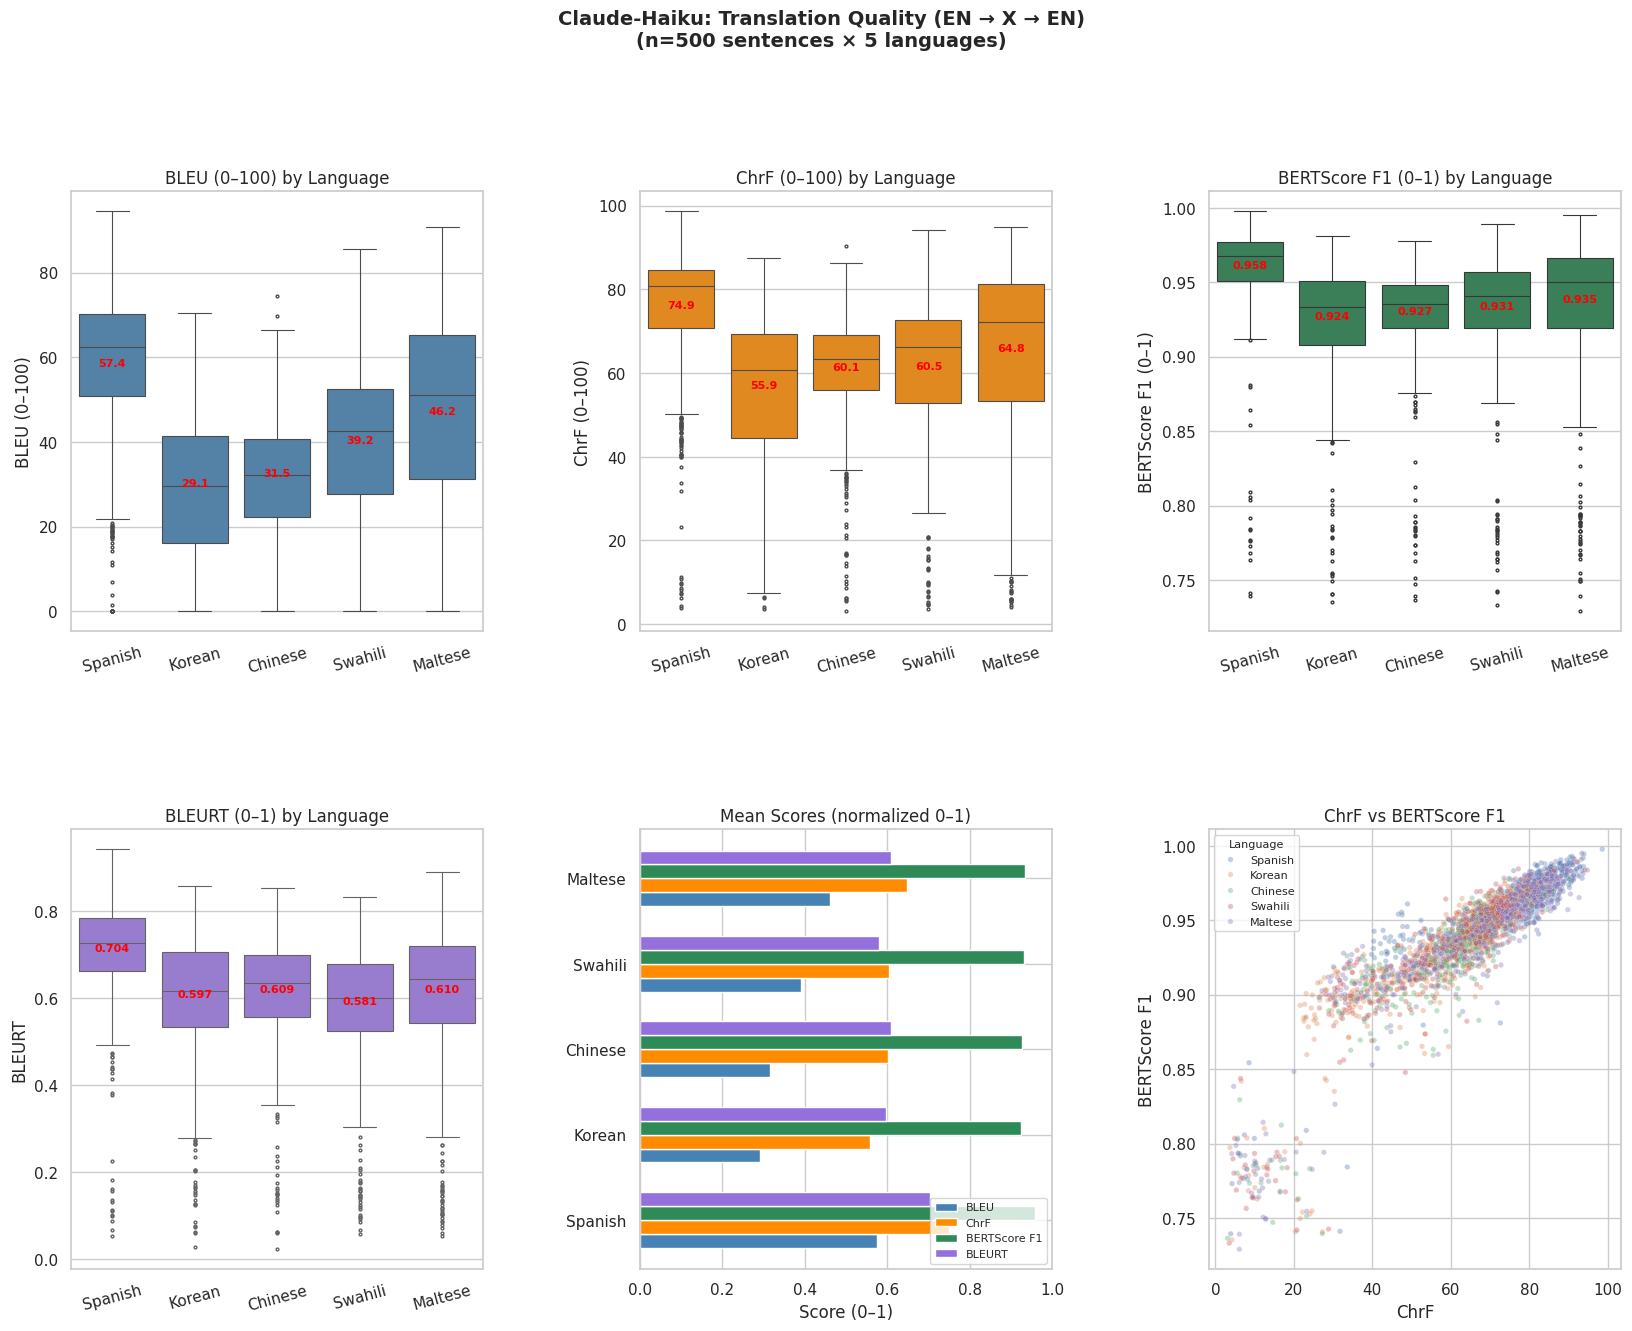

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Claude-Haiku_dashboard.png


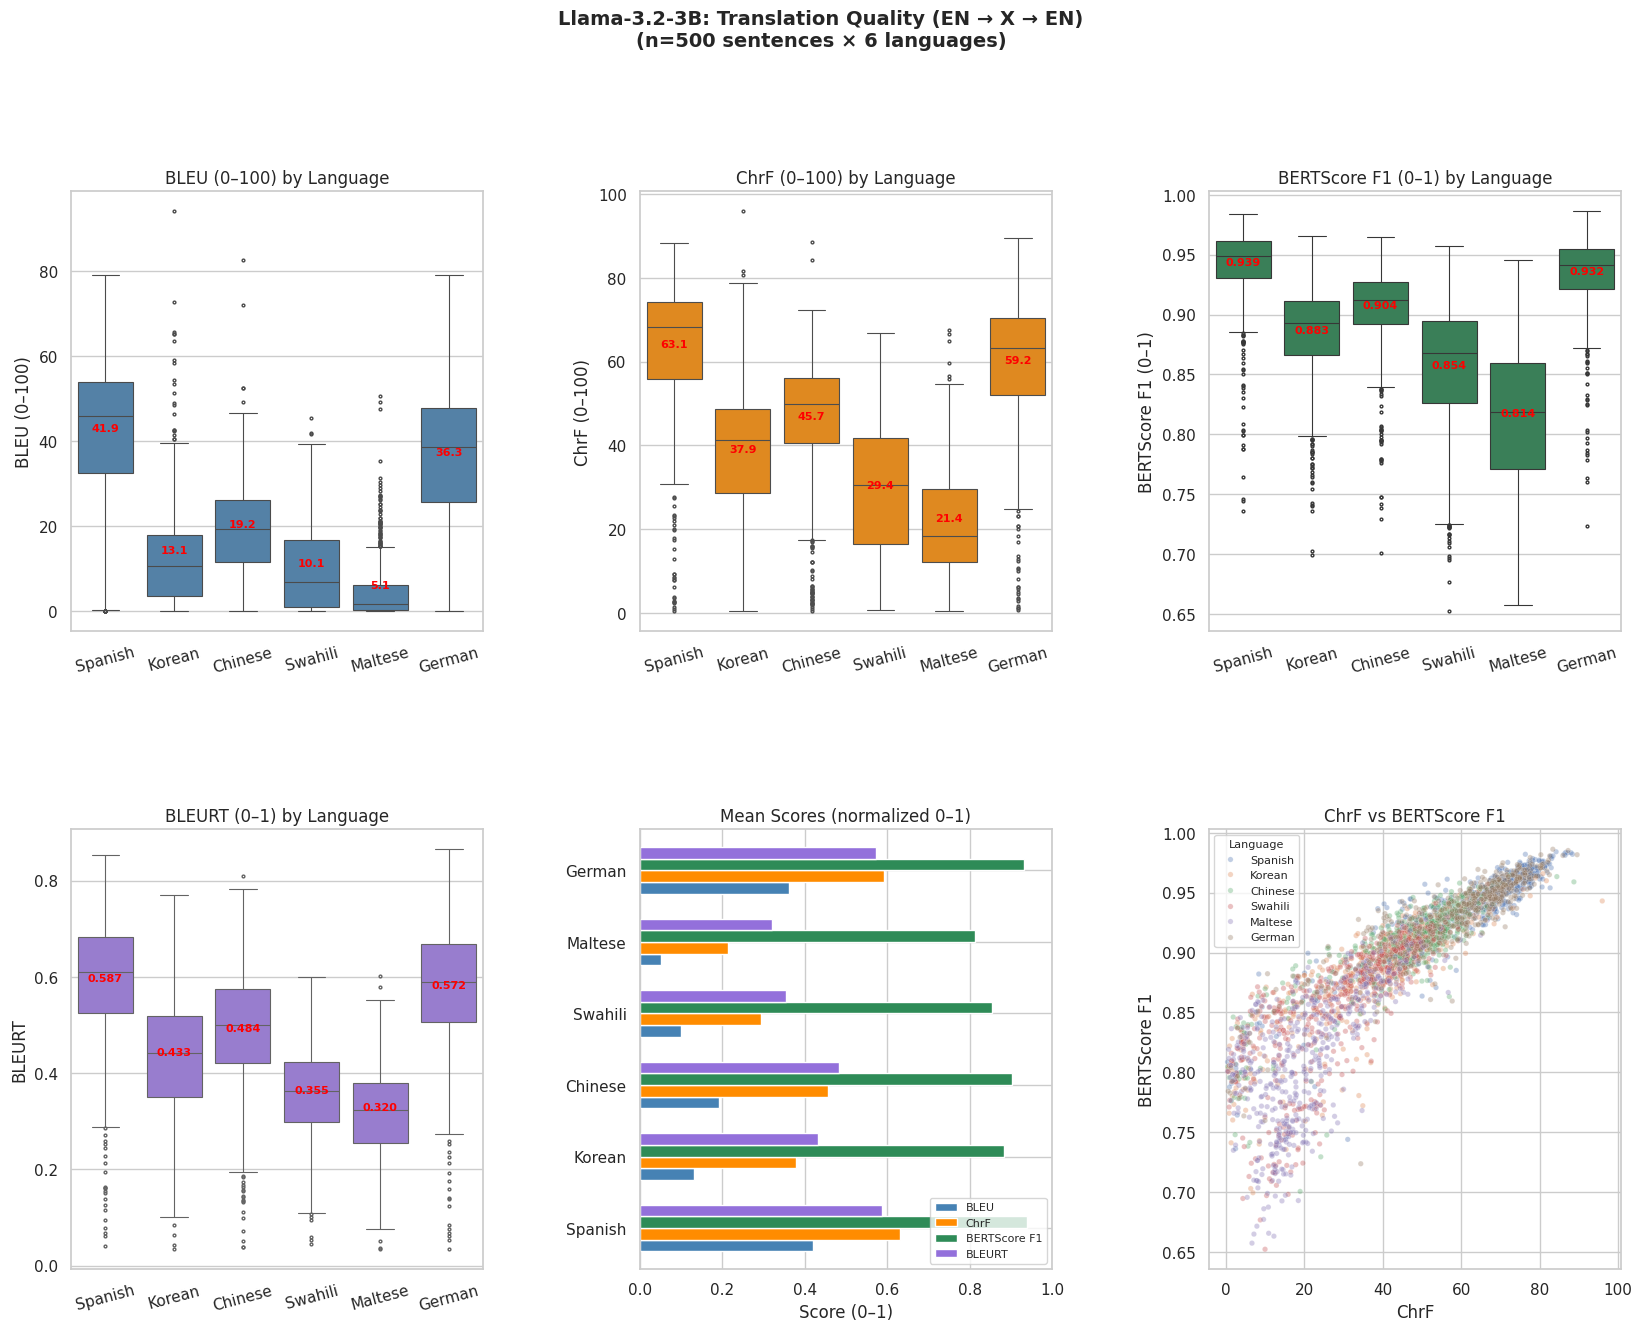

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Llama-32-3B_dashboard.png


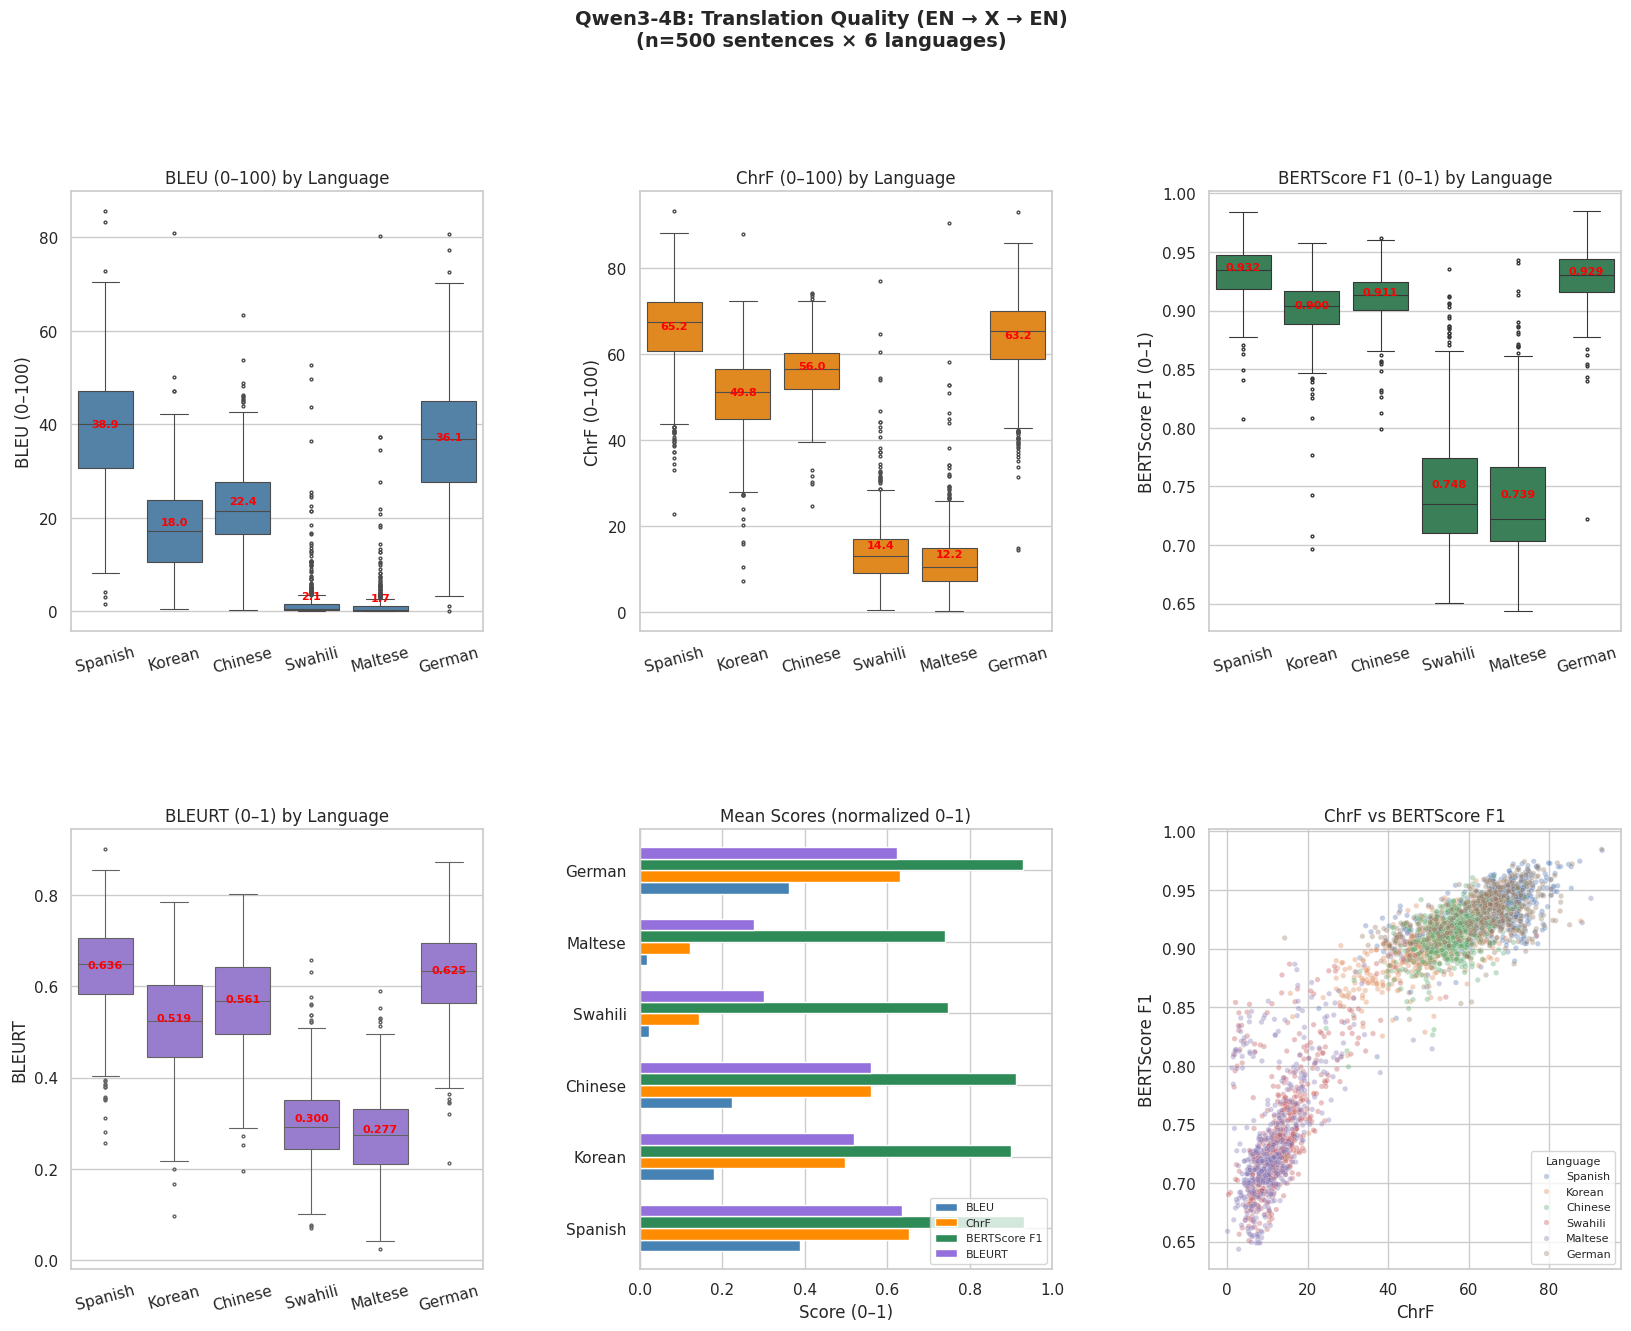

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Qwen3-4B_dashboard.png


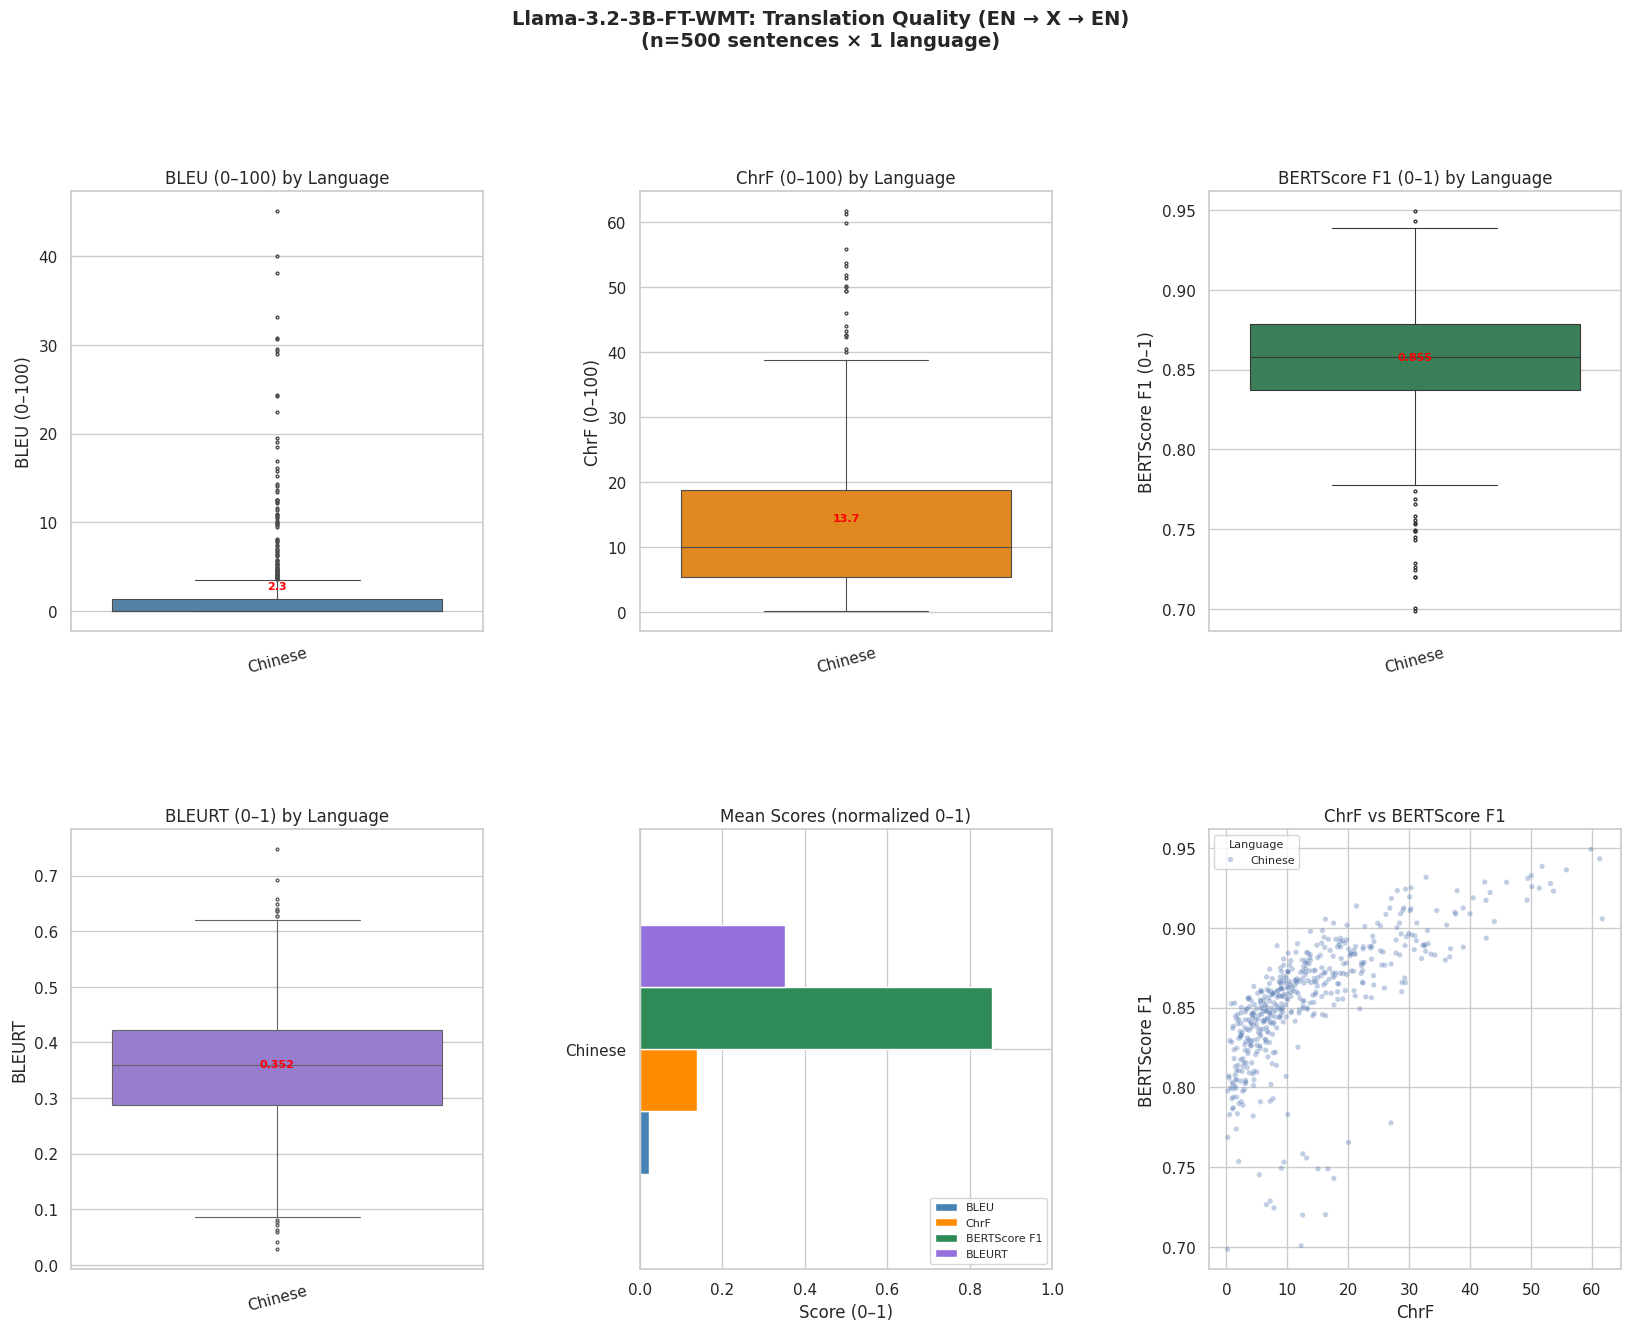

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Llama-32-3B-FT-WMT_dashboard.png


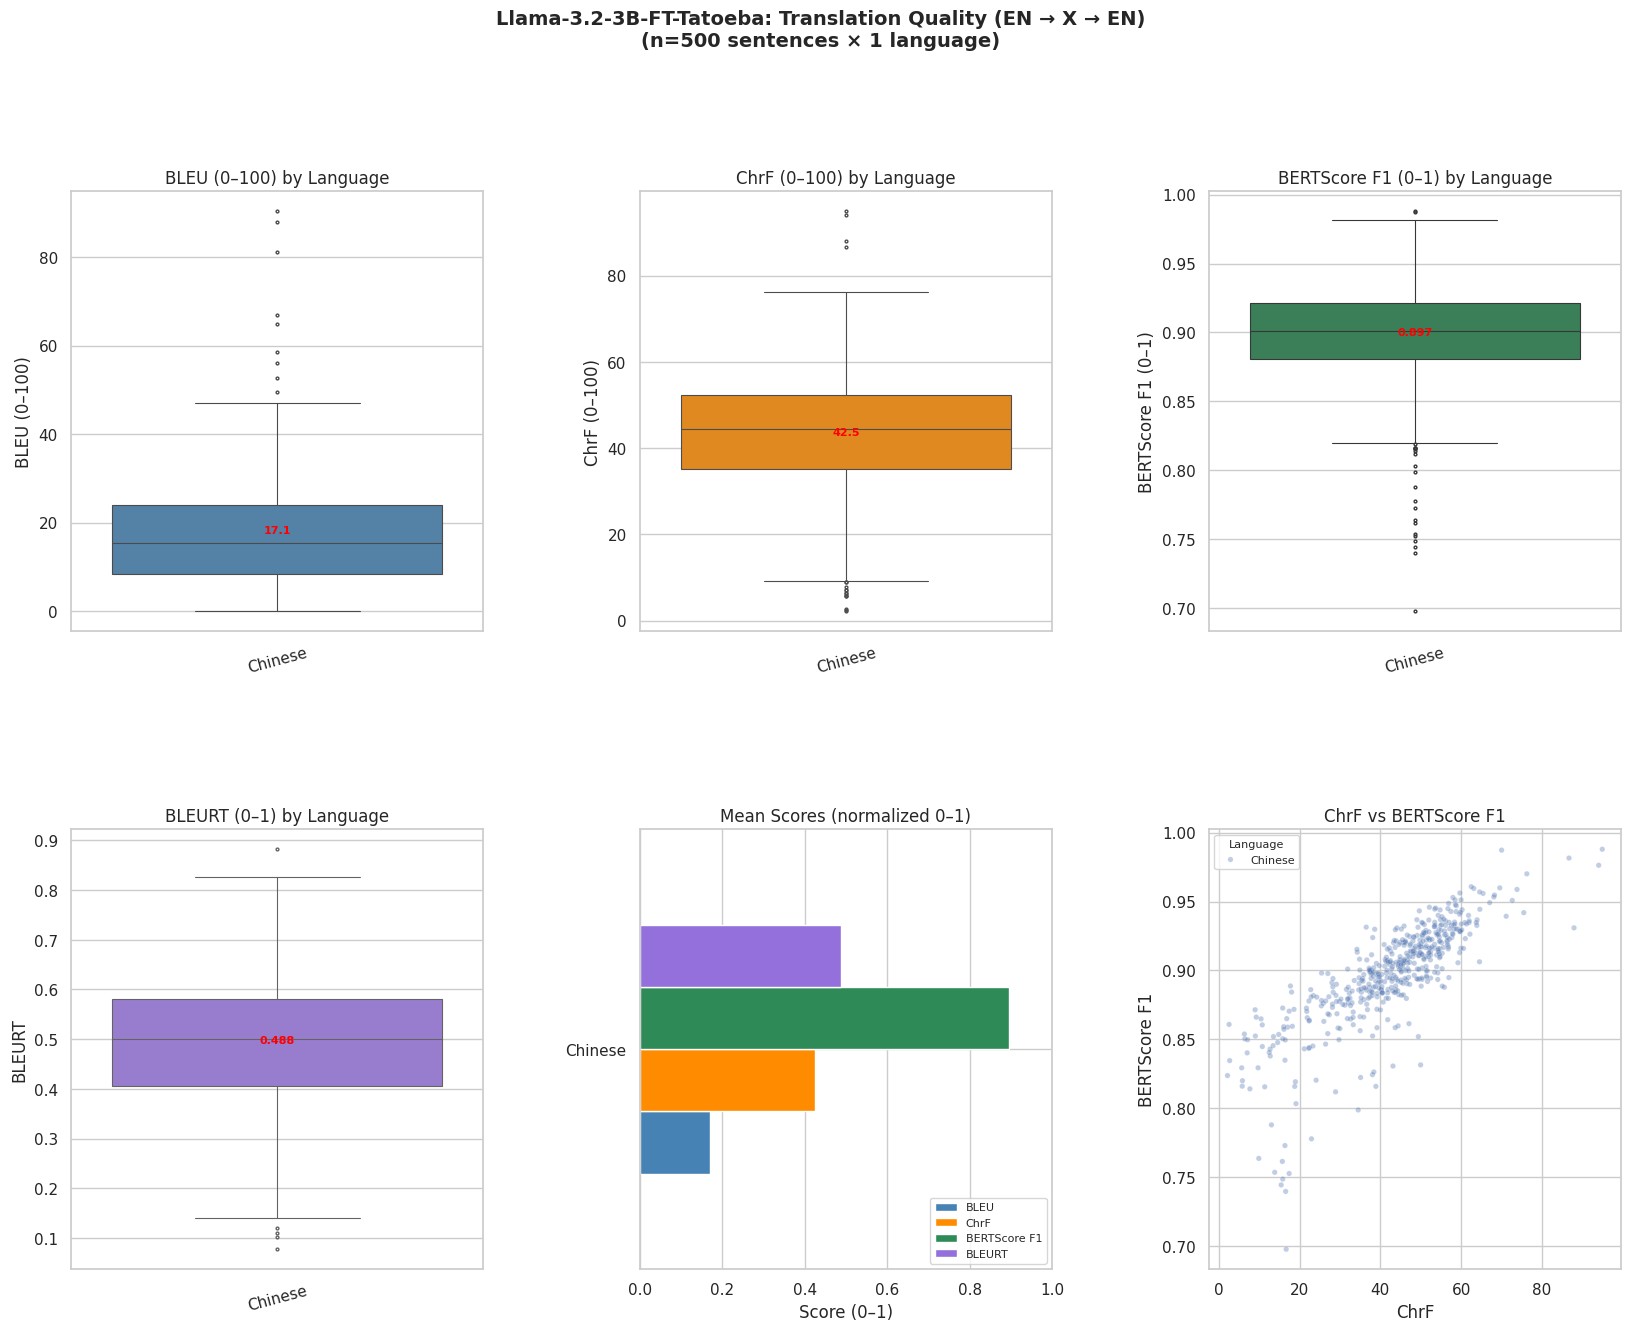

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Llama-32-3B-FT-Tatoeba_dashboard.png


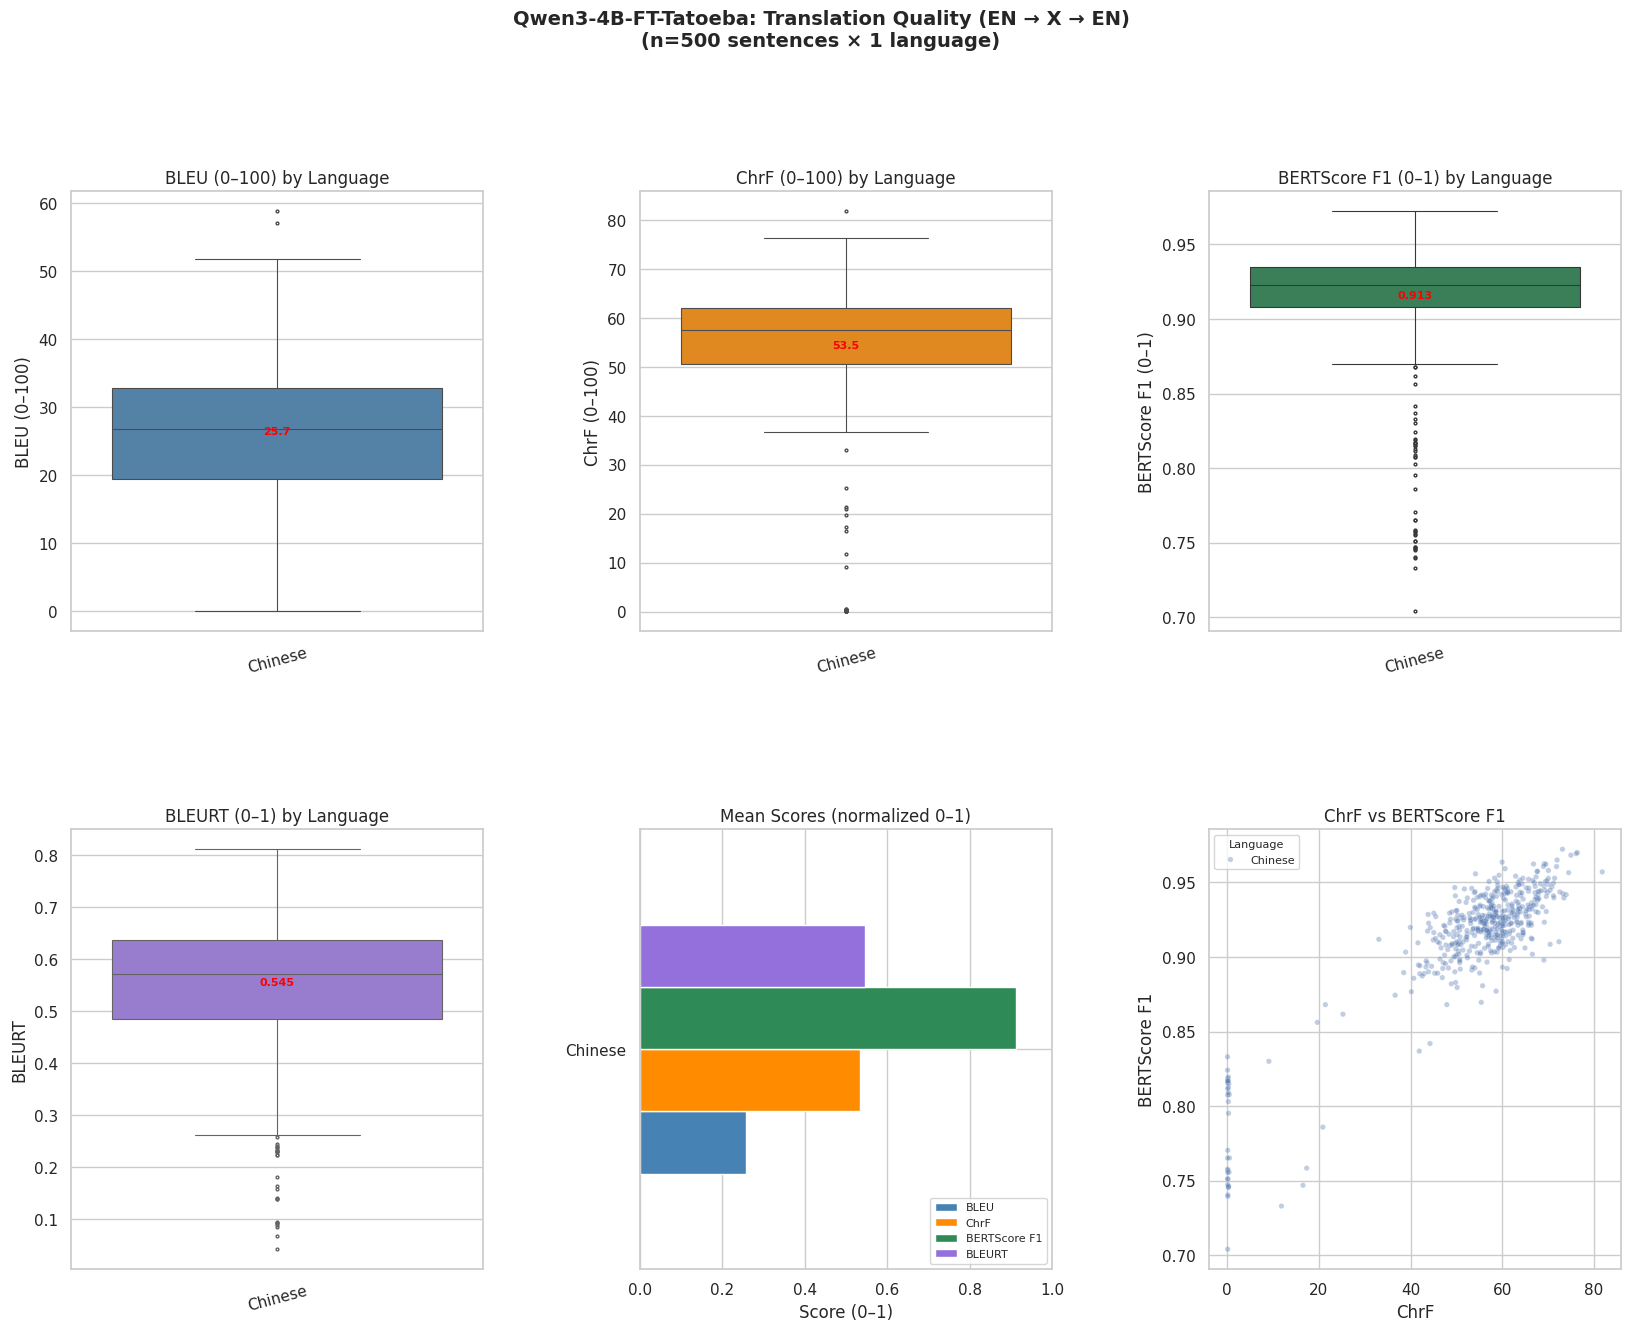

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Qwen3-4B-FT-Tatoeba_dashboard.png


In [31]:
HAS_BLEURT = df["bleurt"].notna().any()


def plot_single_model(model_df, model_name):
    """Generate a 2x3 dashboard for one model."""
    lang_order = [l for l in LANGUAGES if l in model_df["language"].unique()]

    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    box_metrics = [
        ("bleu",         "BLEU (0\u2013100)",       "steelblue"),
        ("chrf",         "ChrF (0\u2013100)",        "darkorange"),
        ("bertscore_f1", "BERTScore F1 (0\u20131)",  "seagreen"),
    ]

    for col, (metric, label, color) in enumerate(box_metrics):
        ax = fig.add_subplot(gs[0, col])
        sns.boxplot(
            data=model_df, x="language", y=metric,
            order=lang_order, color=color,
            fliersize=2, linewidth=0.8, ax=ax,
        )
        means = model_df.groupby("language")[metric].mean()
        fmt = ".1f" if metric != "bertscore_f1" else ".3f"
        for j, lang in enumerate(lang_order):
            ax.text(j, means[lang], f"{means[lang]:{fmt}}",
                    ha="center", va="bottom", fontsize=8, color="red", fontweight="bold")
        ax.set_title(f"{label} by Language")
        ax.set_xlabel("")
        ax.set_ylabel(label)
        ax.tick_params(axis="x", rotation=15)

    # Row 2, col 0: BLEURT box plot (or empty)
    ax_bl = fig.add_subplot(gs[1, 0])
    if HAS_BLEURT and model_df["bleurt"].notna().any():
        sns.boxplot(
            data=model_df, x="language", y="bleurt",
            order=lang_order, color="mediumpurple",
            fliersize=2, linewidth=0.8, ax=ax_bl,
        )
        means_bl = model_df.groupby("language")["bleurt"].mean()
        for j, lang in enumerate(lang_order):
            ax_bl.text(j, means_bl[lang], f"{means_bl[lang]:.3f}",
                       ha="center", va="bottom", fontsize=8, color="red", fontweight="bold")
        ax_bl.set_title("BLEURT (0\u20131) by Language")
        ax_bl.set_xlabel("")
        ax_bl.set_ylabel("BLEURT")
        ax_bl.tick_params(axis="x", rotation=15)
    else:
        ax_bl.text(0.5, 0.5, "BLEURT not available", transform=ax_bl.transAxes,
                   ha="center", va="center", fontsize=12, color="gray")
        ax_bl.set_axis_off()

    # Row 2, col 1: Normalized mean scores bar chart
    ax_bar = fig.add_subplot(gs[1, 1])
    bar_metrics = ["bleu", "chrf", "bertscore_f1"]
    bar_colors = ["steelblue", "darkorange", "seagreen"]
    bar_labels = ["BLEU", "ChrF", "BERTScore F1"]
    if HAS_BLEURT and model_df["bleurt"].notna().any():
        bar_metrics.append("bleurt")
        bar_colors.append("mediumpurple")
        bar_labels.append("BLEURT")

    means_df = model_df.groupby("language")[bar_metrics].mean()
    means_norm = means_df.copy()
    means_norm["bleu"] = means_norm["bleu"] / 100
    means_norm["chrf"] = means_norm["chrf"] / 100
    means_norm = means_norm.loc[[l for l in lang_order if l in means_norm.index]]
    means_norm.plot(kind="barh", ax=ax_bar, color=bar_colors, width=0.65, edgecolor="white")
    ax_bar.set_title("Mean Scores (normalized 0\u20131)")
    ax_bar.set_xlabel("Score (0\u20131)")
    ax_bar.set_ylabel("")
    ax_bar.legend(bar_labels, loc="lower right", fontsize=8)
    ax_bar.set_xlim(0, 1)

    # Row 2, col 2: ChrF vs BERTScore F1 scatter
    ax_sc = fig.add_subplot(gs[1, 2])
    sns.scatterplot(
        data=model_df, x="chrf", y="bertscore_f1",
        hue="language", hue_order=lang_order,
        alpha=0.35, s=15, ax=ax_sc,
    )
    ax_sc.set_title("ChrF vs BERTScore F1")
    ax_sc.set_xlabel("ChrF")
    ax_sc.set_ylabel("BERTScore F1")
    ax_sc.legend(title="Language", fontsize=8, title_fontsize=8)

    n_langs = model_df["language"].nunique()
    n_per_lang = len(model_df) // max(n_langs, 1)
    plt.suptitle(
        f"{model_name}: Translation Quality (EN \u2192 X \u2192 EN)\n"
        f"(n={n_per_lang} sentences \u00d7 {n_langs} language{'s' if n_langs > 1 else ''})",
        fontsize=14, fontweight="bold", y=1.01,
    )

    safe_name = model_name.replace(" ", "_").replace(".", "")
    path = os.path.join(OUTPUT_DIR, f"{safe_name}_dashboard.png")
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved to {path}")


for model_name in df["model"].unique():
    plot_single_model(df[df["model"] == model_name], model_name)

## Llama-3.2-3B Dashboard (Filtered: ChrF > 10)

Removes low-quality translations (ChrF ≤ 10) to see the distribution without noise from failed translations.

Loaded 10000 rows from all_results_scored.csv

Llama-3.2-3B: 3000 total, 0 removed (ChrF <= 0), 3000 remaining
Removed per language:
  Spanish: 0 removed (500 -> 500)
  Korean: 0 removed (500 -> 500)
  Chinese: 0 removed (500 -> 500)
  Swahili: 0 removed (500 -> 500)
  Maltese: 0 removed (500 -> 500)


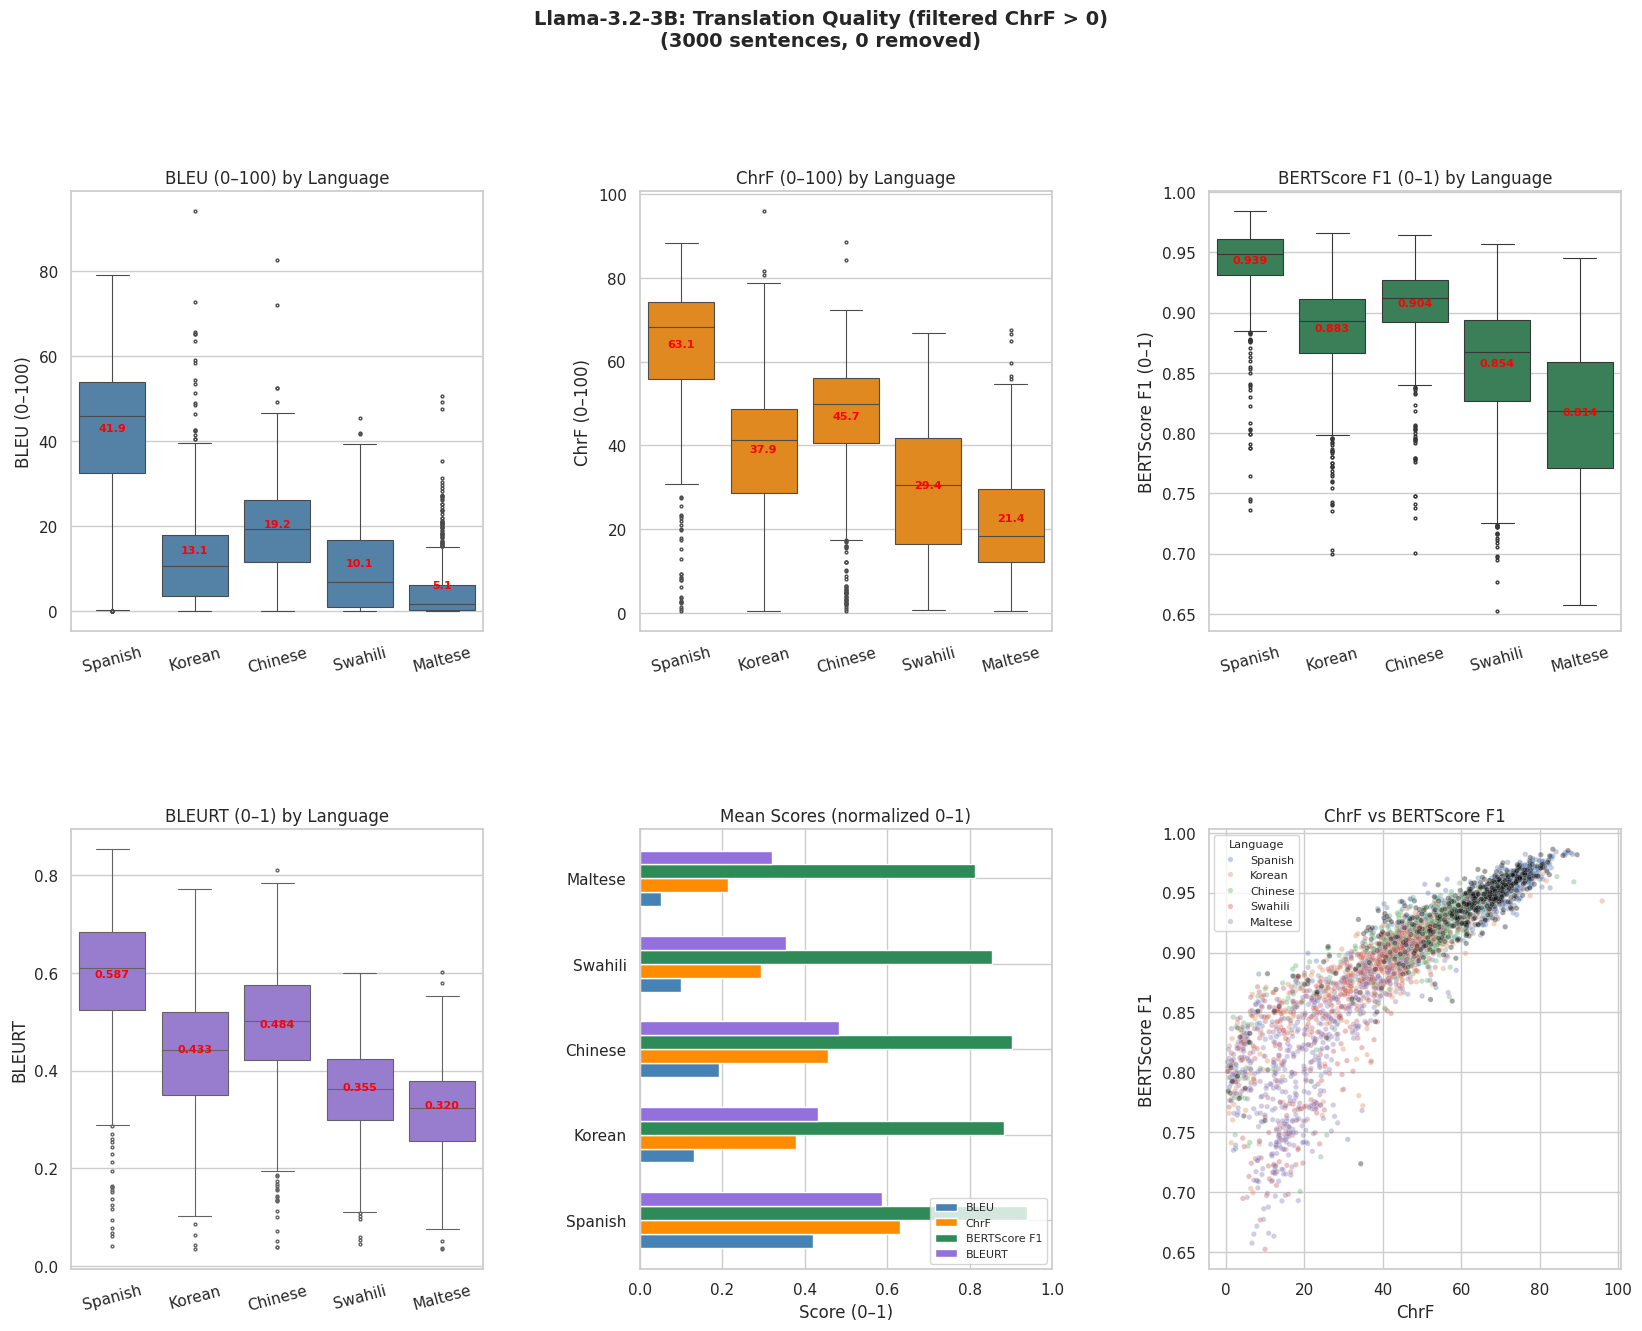

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Llama-32-3B_filtered_dashboard.png


In [32]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "/content/drive/MyDrive/Coding project/evaluation_results/"
LANGUAGES = ["Spanish", "Korean", "Chinese", "Swahili", "Maltese"]
CHRF_CUTOFF = 0

df = pd.read_csv(os.path.join(OUTPUT_DIR, "all_results_scored.csv"))
HAS_BLEURT = df["bleurt"].notna().any()
print(f"Loaded {len(df)} rows from all_results_scored.csv")

llama_df = df[df["model"] == "Llama-3.2-3B"].copy()
llama_filtered = llama_df[llama_df["chrf"] > CHRF_CUTOFF].copy()

n_removed = len(llama_df) - len(llama_filtered)
print(f"\nLlama-3.2-3B: {len(llama_df)} total, {n_removed} removed (ChrF <= {CHRF_CUTOFF}), {len(llama_filtered)} remaining")
print("Removed per language:")
for lang in LANGUAGES:
    before = len(llama_df[llama_df["language"] == lang])
    after = len(llama_filtered[llama_filtered["language"] == lang])
    print(f"  {lang}: {before - after} removed ({before} -> {after})")

# --- Filtered dashboard (2x3 layout) ---
lang_order = [l for l in LANGUAGES if l in llama_filtered["language"].unique()]

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

box_metrics = [
    ("bleu",         "BLEU (0–100)",       "steelblue"),
    ("chrf",         "ChrF (0–100)",        "darkorange"),
    ("bertscore_f1", "BERTScore F1 (0–1)",  "seagreen"),
]

for col, (metric, label, color) in enumerate(box_metrics):
    ax = fig.add_subplot(gs[0, col])
    sns.boxplot(
        data=llama_filtered, x="language", y=metric,
        order=lang_order, color=color,
        fliersize=2, linewidth=0.8, ax=ax,
    )
    means = llama_filtered.groupby("language")[metric].mean()
    fmt = ".1f" if metric != "bertscore_f1" else ".3f"
    for j, lang in enumerate(lang_order):
        ax.text(j, means[lang], f"{means[lang]:{fmt}}",
                ha="center", va="bottom", fontsize=8, color="red", fontweight="bold")
    ax.set_title(f"{label} by Language")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=15)

ax_bl = fig.add_subplot(gs[1, 0])
if HAS_BLEURT and llama_filtered["bleurt"].notna().any():
    sns.boxplot(
        data=llama_filtered, x="language", y="bleurt",
        order=lang_order, color="mediumpurple",
        fliersize=2, linewidth=0.8, ax=ax_bl,
    )
    means_bl = llama_filtered.groupby("language")["bleurt"].mean()
    for j, lang in enumerate(lang_order):
        ax_bl.text(j, means_bl[lang], f"{means_bl[lang]:.3f}",
                   ha="center", va="bottom", fontsize=8, color="red", fontweight="bold")
    ax_bl.set_title("BLEURT (0–1) by Language")
    ax_bl.set_xlabel("")
    ax_bl.set_ylabel("BLEURT")
    ax_bl.tick_params(axis="x", rotation=15)
else:
    ax_bl.text(0.5, 0.5, "BLEURT not available", transform=ax_bl.transAxes,
               ha="center", va="center", fontsize=12, color="gray")
    ax_bl.set_axis_off()

ax_bar = fig.add_subplot(gs[1, 1])
bar_metrics = ["bleu", "chrf", "bertscore_f1"]
bar_colors = ["steelblue", "darkorange", "seagreen"]
bar_labels = ["BLEU", "ChrF", "BERTScore F1"]
if HAS_BLEURT and llama_filtered["bleurt"].notna().any():
    bar_metrics.append("bleurt")
    bar_colors.append("mediumpurple")
    bar_labels.append("BLEURT")

means_df = llama_filtered.groupby("language")[bar_metrics].mean()
means_norm = means_df.copy()
means_norm["bleu"] = means_norm["bleu"] / 100
means_norm["chrf"] = means_norm["chrf"] / 100
means_norm = means_norm.loc[[l for l in lang_order if l in means_norm.index]]
means_norm.plot(kind="barh", ax=ax_bar, color=bar_colors, width=0.65, edgecolor="white")
ax_bar.set_title("Mean Scores (normalized 0–1)")
ax_bar.set_xlabel("Score (0–1)")
ax_bar.set_ylabel("")
ax_bar.legend(bar_labels, loc="lower right", fontsize=8)
ax_bar.set_xlim(0, 1)

ax_sc = fig.add_subplot(gs[1, 2])
sns.scatterplot(
    data=llama_filtered, x="chrf", y="bertscore_f1",
    hue="language", hue_order=lang_order,
    alpha=0.35, s=15, ax=ax_sc,
)
ax_sc.set_title("ChrF vs BERTScore F1")
ax_sc.set_xlabel("ChrF")
ax_sc.set_ylabel("BERTScore F1")
ax_sc.legend(title="Language", fontsize=8, title_fontsize=8)

plt.suptitle(
    f"Llama-3.2-3B: Translation Quality (filtered ChrF > {CHRF_CUTOFF})\n"
    f"({len(llama_filtered)} sentences, {n_removed} removed)",
    fontsize=14, fontweight="bold", y=1.01,
)
path = os.path.join(OUTPUT_DIR, "Llama-32-3B_filtered_dashboard.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to {path}")

## Cross-Model Comparison

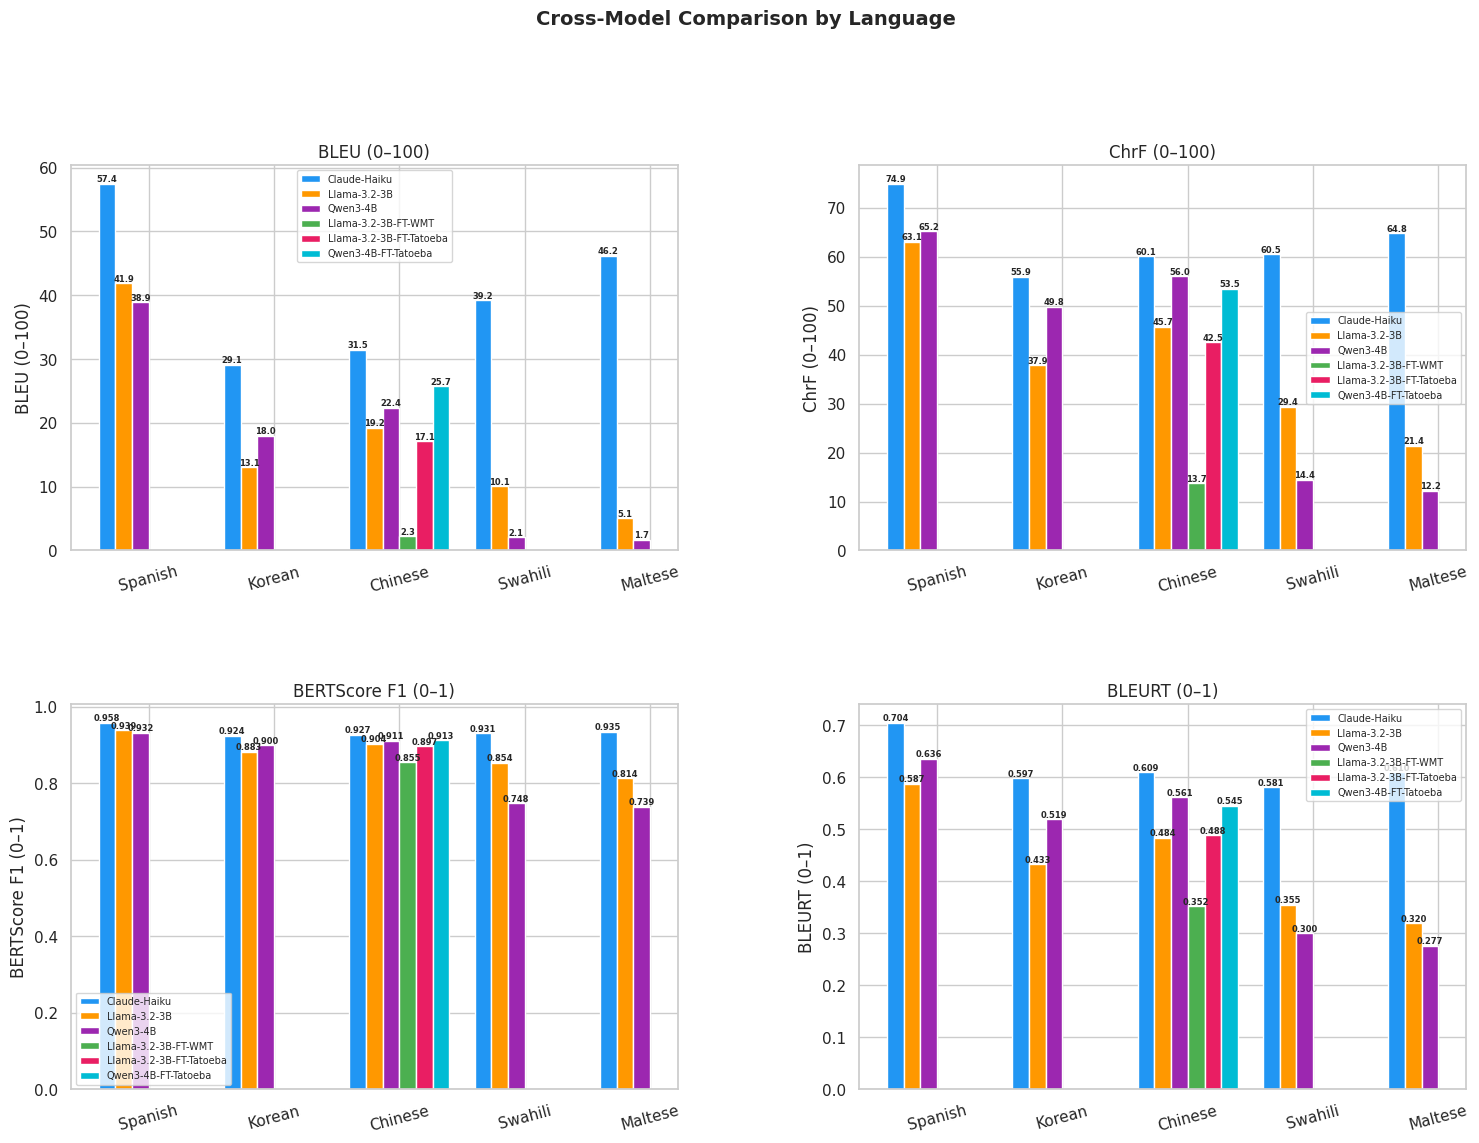

Saved to /content/drive/MyDrive/Coding project/evaluation_results/cross_model_grouped_bars.png


In [33]:
# Figure A: Grouped bar charts — one panel per metric, languages on x-axis, bars by model

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

plot_metrics = [("bleu", "BLEU (0–100)"), ("chrf", "ChrF (0–100)"),
                ("bertscore_f1", "BERTScore F1 (0–1)")]
if HAS_BLEURT:
    plot_metrics.append(("bleurt", "BLEURT (0–1)"))

model_order = [m for m in ["Claude-Haiku", "Llama-3.2-3B", "Qwen3-4B",
                            "Llama-3.2-3B-FT-WMT", "Llama-3.2-3B-FT-Tatoeba",
                            "Qwen3-4B-FT-Tatoeba"]
               if m in df["model"].unique()]
n_models = len(model_order)
width = 0.8 / max(n_models, 1)

for idx, (metric, label) in enumerate(plot_metrics):
    ax = axes[idx // 2, idx % 2]
    means = df.groupby(["language", "model"])[metric].mean().unstack(fill_value=0)
    means = means.reindex(index=LANGUAGES, columns=model_order).fillna(0)

    x = np.arange(len(LANGUAGES))
    for i, model in enumerate(model_order):
        values = means[model].values
        mask = values > 0
        bars = ax.bar(x[mask] + i * width, values[mask], width,
                      label=model, color=MODEL_COLORS[model], edgecolor="white")
        for bar, val in zip(bars, values[mask]):
            fmt = ".1f" if metric in ("bleu", "chrf") else ".3f"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:{fmt}}", ha="center", va="bottom", fontsize=6, fontweight="bold")

    ax.set_xticks(x + width * (n_models - 1) / 2)
    ax.set_xticklabels(LANGUAGES, rotation=15)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=7)

if len(plot_metrics) < 4:
    axes[1, 1].set_visible(False)

plt.suptitle("Cross-Model Comparison by Language", fontsize=14, fontweight="bold", y=1.01)
path = os.path.join(OUTPUT_DIR, "cross_model_grouped_bars.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to {path}")

/tmp/ipykernel_5703/3998156646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5703/3998156646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5703/3998156646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_5703/3998156646.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


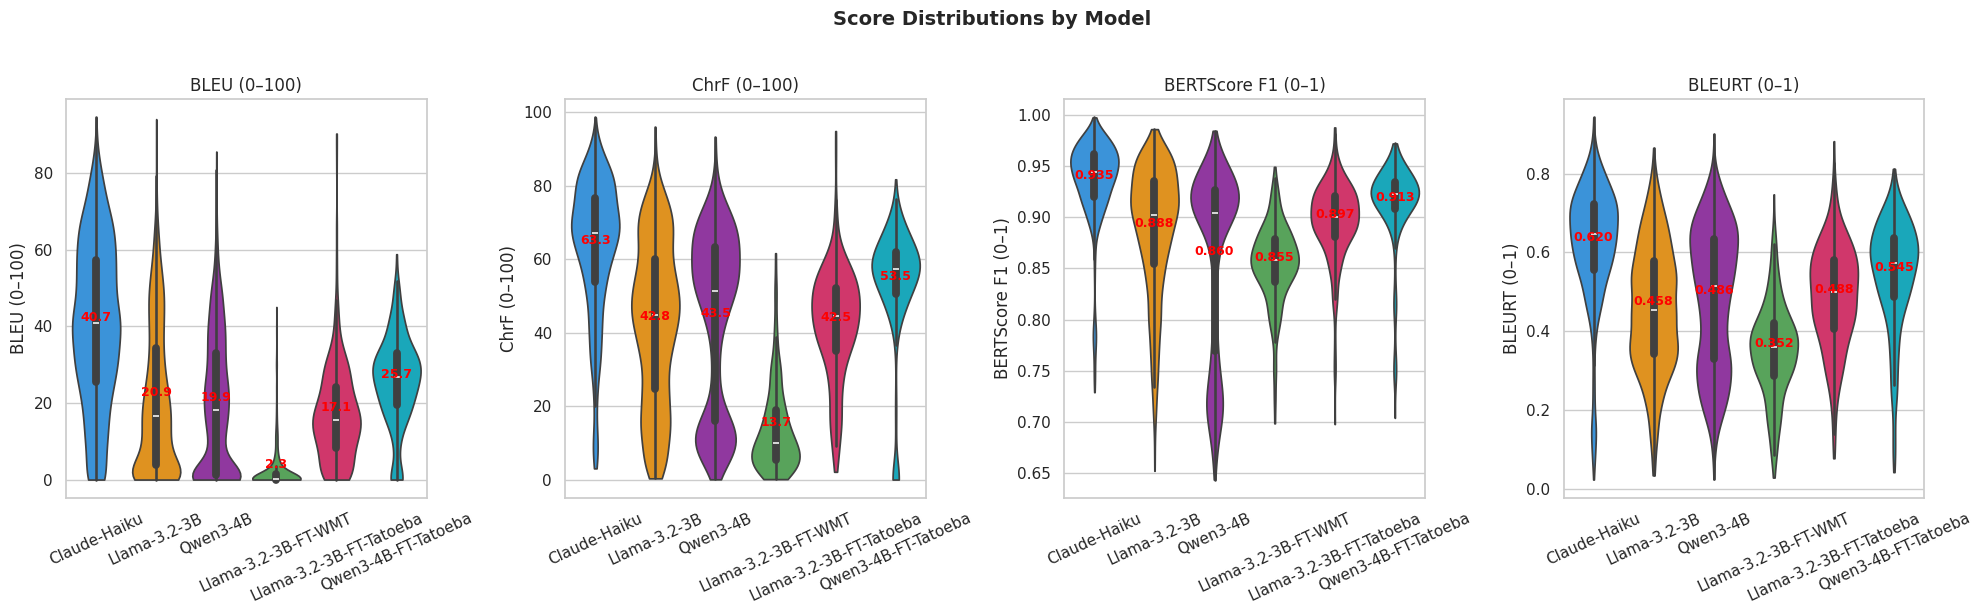

Saved to /content/drive/MyDrive/Coding project/evaluation_results/cross_model_violins.png


In [34]:
# Figure B: Violin plots — full score distribution per model

n_metrics = len(plot_metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 6))
if n_metrics == 1:
    axes = [axes]

for ax, (metric, label) in zip(axes, plot_metrics):
    sns.violinplot(
        data=df, x="model", y=metric,
        order=model_order,
        palette=MODEL_COLORS,
        inner="box", cut=0, ax=ax,
    )
    means = df.groupby("model")[metric].mean()
    fmt = ".1f" if metric in ("bleu", "chrf") else ".3f"
    for j, model in enumerate(model_order):
        ax.text(j, means[model], f"{means[model]:{fmt}}",
                ha="center", va="bottom", fontsize=9, color="red", fontweight="bold")
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle("Score Distributions by Model", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "cross_model_violins.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved to {path}")

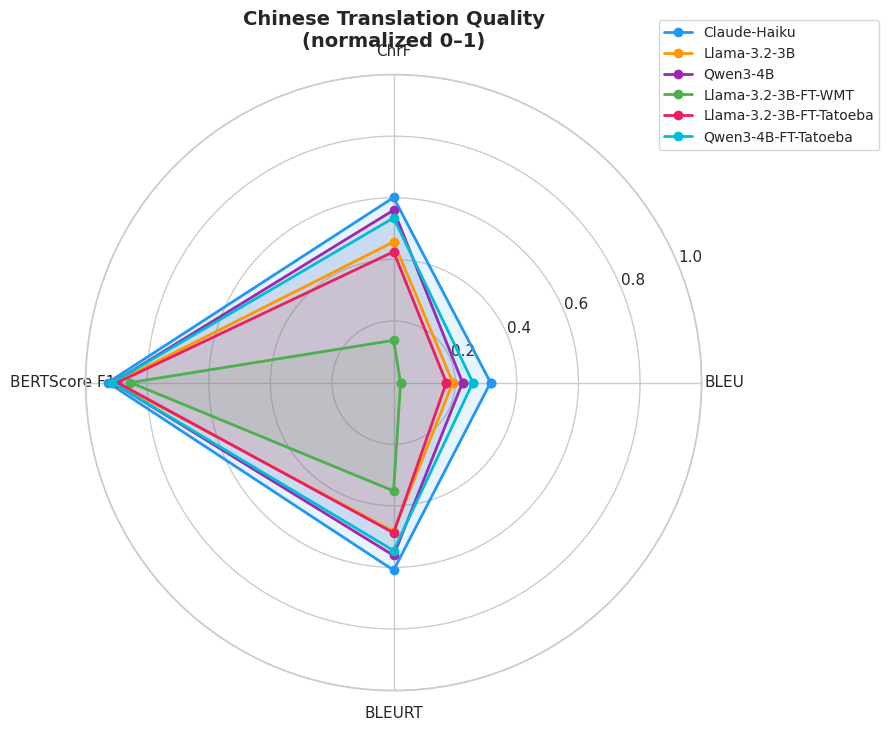

Saved to /content/drive/MyDrive/Coding project/evaluation_results/chinese_radar.png


In [35]:
# Figure C: Radar chart — Chinese only, all 3 models

chinese_df = df[df["language"] == "Chinese"]
chinese_models = [m for m in model_order if m in chinese_df["model"].unique()]

if len(chinese_models) >= 2:
    radar_metrics = ["bleu", "chrf", "bertscore_f1"]
    radar_labels = ["BLEU", "ChrF", "BERTScore F1"]
    if HAS_BLEURT:
        radar_metrics.append("bleurt")
        radar_labels.append("BLEURT")

    chinese_means = chinese_df.groupby("model")[radar_metrics].mean()
    # Normalize to 0-1 for radar
    norm_means = chinese_means.copy()
    norm_means["bleu"] = norm_means["bleu"] / 100
    norm_means["chrf"] = norm_means["chrf"] / 100

    angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for model in chinese_models:
        values = norm_means.loc[model].values.tolist()
        values += values[:1]
        ax.plot(angles, values, "o-", label=model, color=MODEL_COLORS[model], linewidth=2)
        ax.fill(angles, values, alpha=0.1, color=MODEL_COLORS[model])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title("Chinese Translation Quality\n(normalized 0\u20131)", fontsize=14, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)

    path = os.path.join(OUTPUT_DIR, "chinese_radar.png")
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved to {path}")
else:
    print("Not enough Chinese models for radar chart (need at least 2).")

## Fine-Tuned Chinese Comparison

Direct comparison of Chinese translation quality: base models vs their fine-tuned variants (Llama WMT, Llama Tatoeba, Qwen Tatoeba), with Claude-Haiku as reference.

In [36]:
# --- Numerical comparison: base vs fine-tuned (Chinese) ---
chinese_df = df[df["language"] == "Chinese"].copy()
compare_metrics = ["bleu", "chrf", "bertscore_f1"]
if df["bleurt"].notna().any():
    compare_metrics.append("bleurt")

compare_labels = {"bleu": "BLEU", "chrf": "ChrF", "bertscore_f1": "BERTScore F1", "bleurt": "BLEURT"}

chinese_means = chinese_df.groupby("model")[compare_metrics].mean()

all_chinese_models = [m for m in chinese_means.index if m in chinese_df["model"].unique()]

comparison = chinese_means.loc[all_chinese_models].copy()
comparison.index.name = "Model"
comparison.columns = [compare_labels[m] for m in compare_metrics]

print("=" * 70)
print("Chinese Translation — Mean Scores")
print("=" * 70)
print(comparison.round(4).to_string())

# Difference and % change: each FT model vs its base
ft_pairs = [
    ("Llama-3.2-3B-FT-WMT",     "Llama-3.2-3B"),
    ("Llama-3.2-3B-FT-Tatoeba", "Llama-3.2-3B"),
    ("Qwen3-4B-FT-Tatoeba",     "Qwen3-4B"),
]

for ft_name, base_name in ft_pairs:
    if ft_name not in chinese_means.index or base_name not in chinese_means.index:
        continue
    short = ft_name.split("FT-")[-1] if "FT-" in ft_name else ft_name
    print(f"\n{'─' * 70}")
    print(f"{ft_name} vs {base_name}")
    print(f"{'─' * 70}")

    diff_df = pd.DataFrame({
        base_name: chinese_means.loc[base_name],
        ft_name: chinese_means.loc[ft_name],
    })
    diff_df["Difference"] = diff_df[ft_name] - diff_df[base_name]
    diff_df["Change (%)"] = (diff_df["Difference"] / diff_df[base_name] * 100).round(2)
    diff_df.index = [compare_labels[m] for m in compare_metrics]
    print(diff_df.round(4).to_string())

    improved = (diff_df["Difference"] > 0).sum()
    print(f"\n→ Fine-tuned ({short}) is better on {improved}/{len(compare_metrics)} metrics")

# Also show Claude-Haiku as reference
if "Claude-Haiku" in chinese_means.index:
    print(f"\n{'─' * 70}")
    print(f"Reference: Claude-Haiku (Chinese)")
    print(f"{'─' * 70}")
    ref = chinese_means.loc["Claude-Haiku"]
    ref.index = [compare_labels[m] for m in compare_metrics]
    print(ref.round(4).to_string())

Chinese Translation — Mean Scores
                            BLEU     ChrF  BERTScore F1  BLEURT
Model                                                          
Claude-Haiku             31.4712  60.0922        0.9275  0.6093
Llama-3.2-3B             19.2306  45.7086        0.9038  0.4837
Llama-3.2-3B-FT-Tatoeba  17.1189  42.4960        0.8966  0.4880
Llama-3.2-3B-FT-WMT       2.2586  13.7374        0.8545  0.3519
Qwen3-4B                 22.3890  56.0002        0.9114  0.5613
Qwen3-4B-FT-Tatoeba      25.7430  53.4676        0.9127  0.5455

──────────────────────────────────────────────────────────────────────
Llama-3.2-3B-FT-WMT vs Llama-3.2-3B
──────────────────────────────────────────────────────────────────────
              Llama-3.2-3B  Llama-3.2-3B-FT-WMT  Difference  Change (%)
BLEU               19.2306               2.2586    -16.9721      -88.26
ChrF               45.7086              13.7374    -31.9712      -69.95
BERTScore F1        0.9038               0.8545     -0.0493

/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


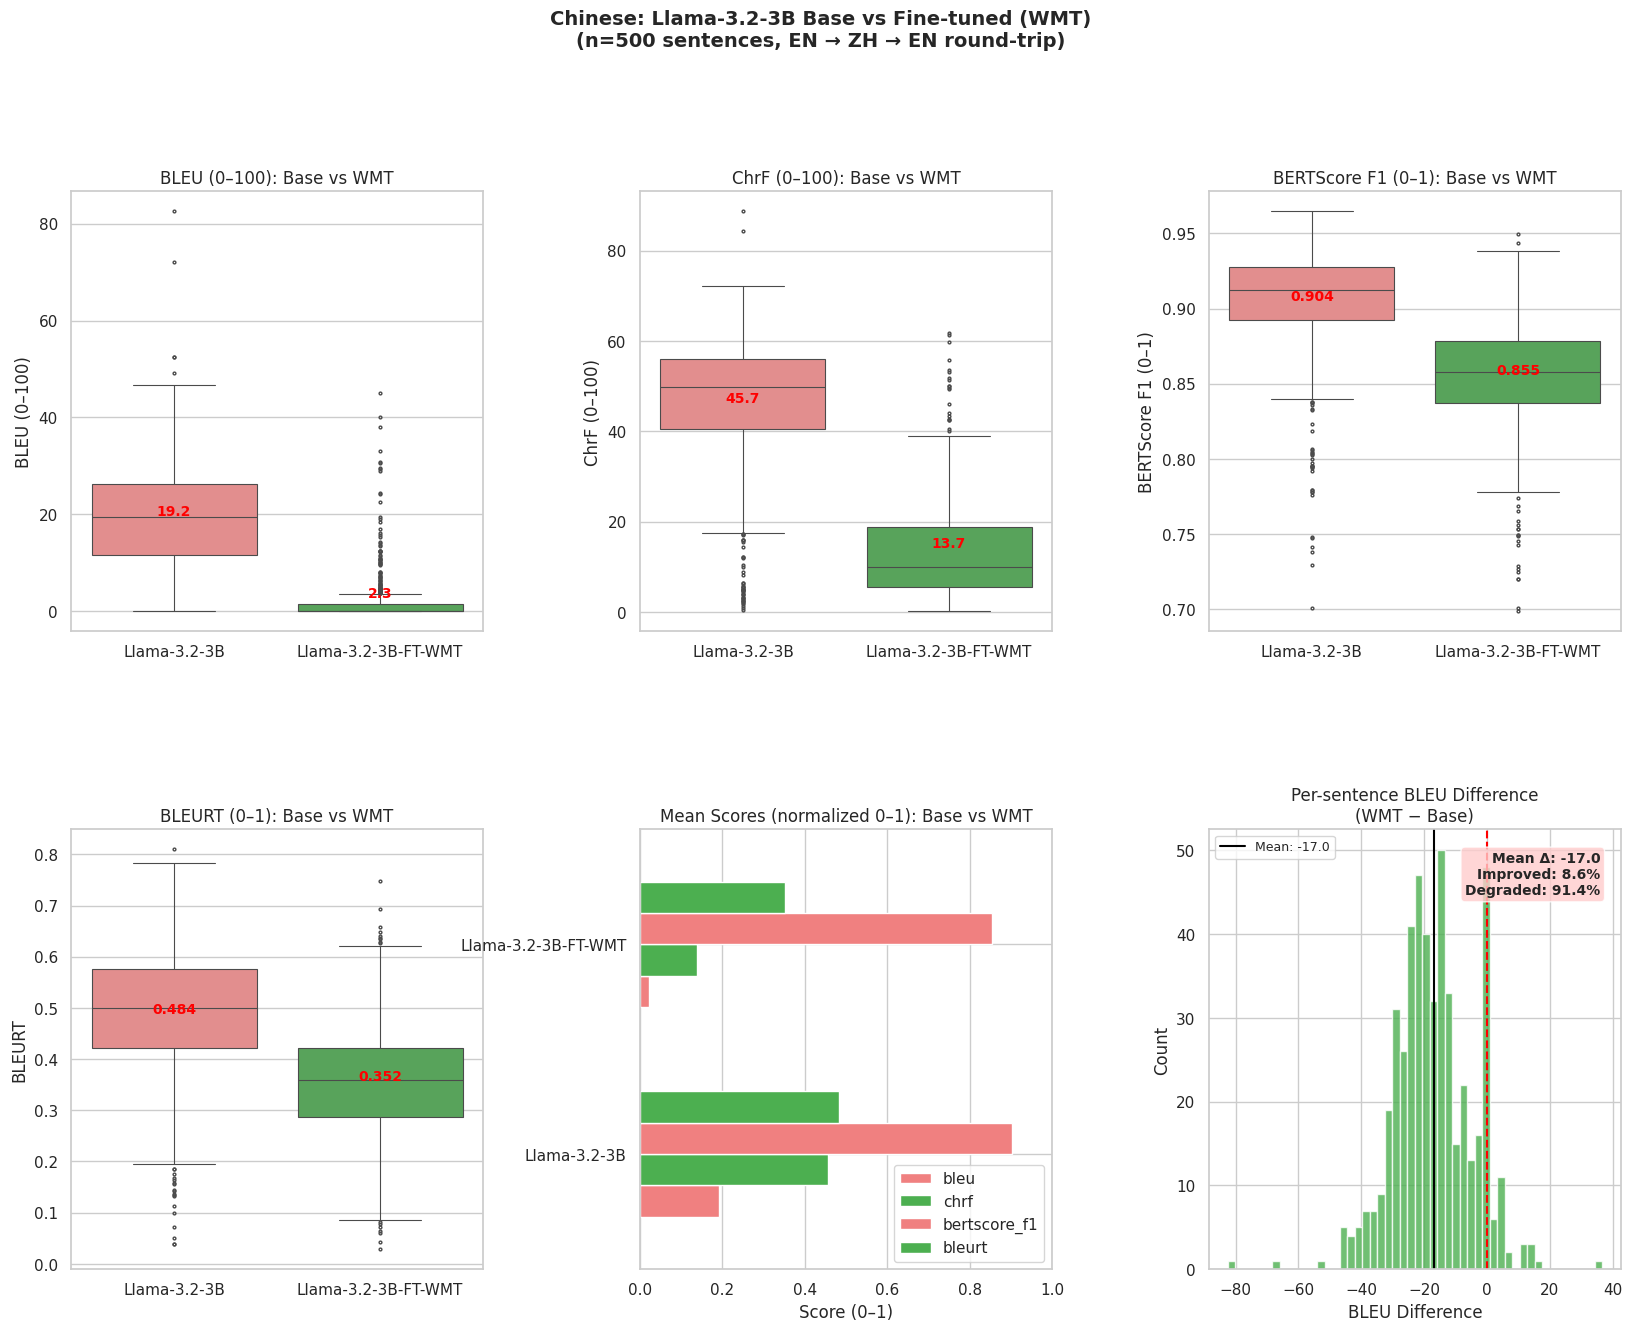

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Llama-32-3B-FT-WMT_vs_base_dashboard.png



/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


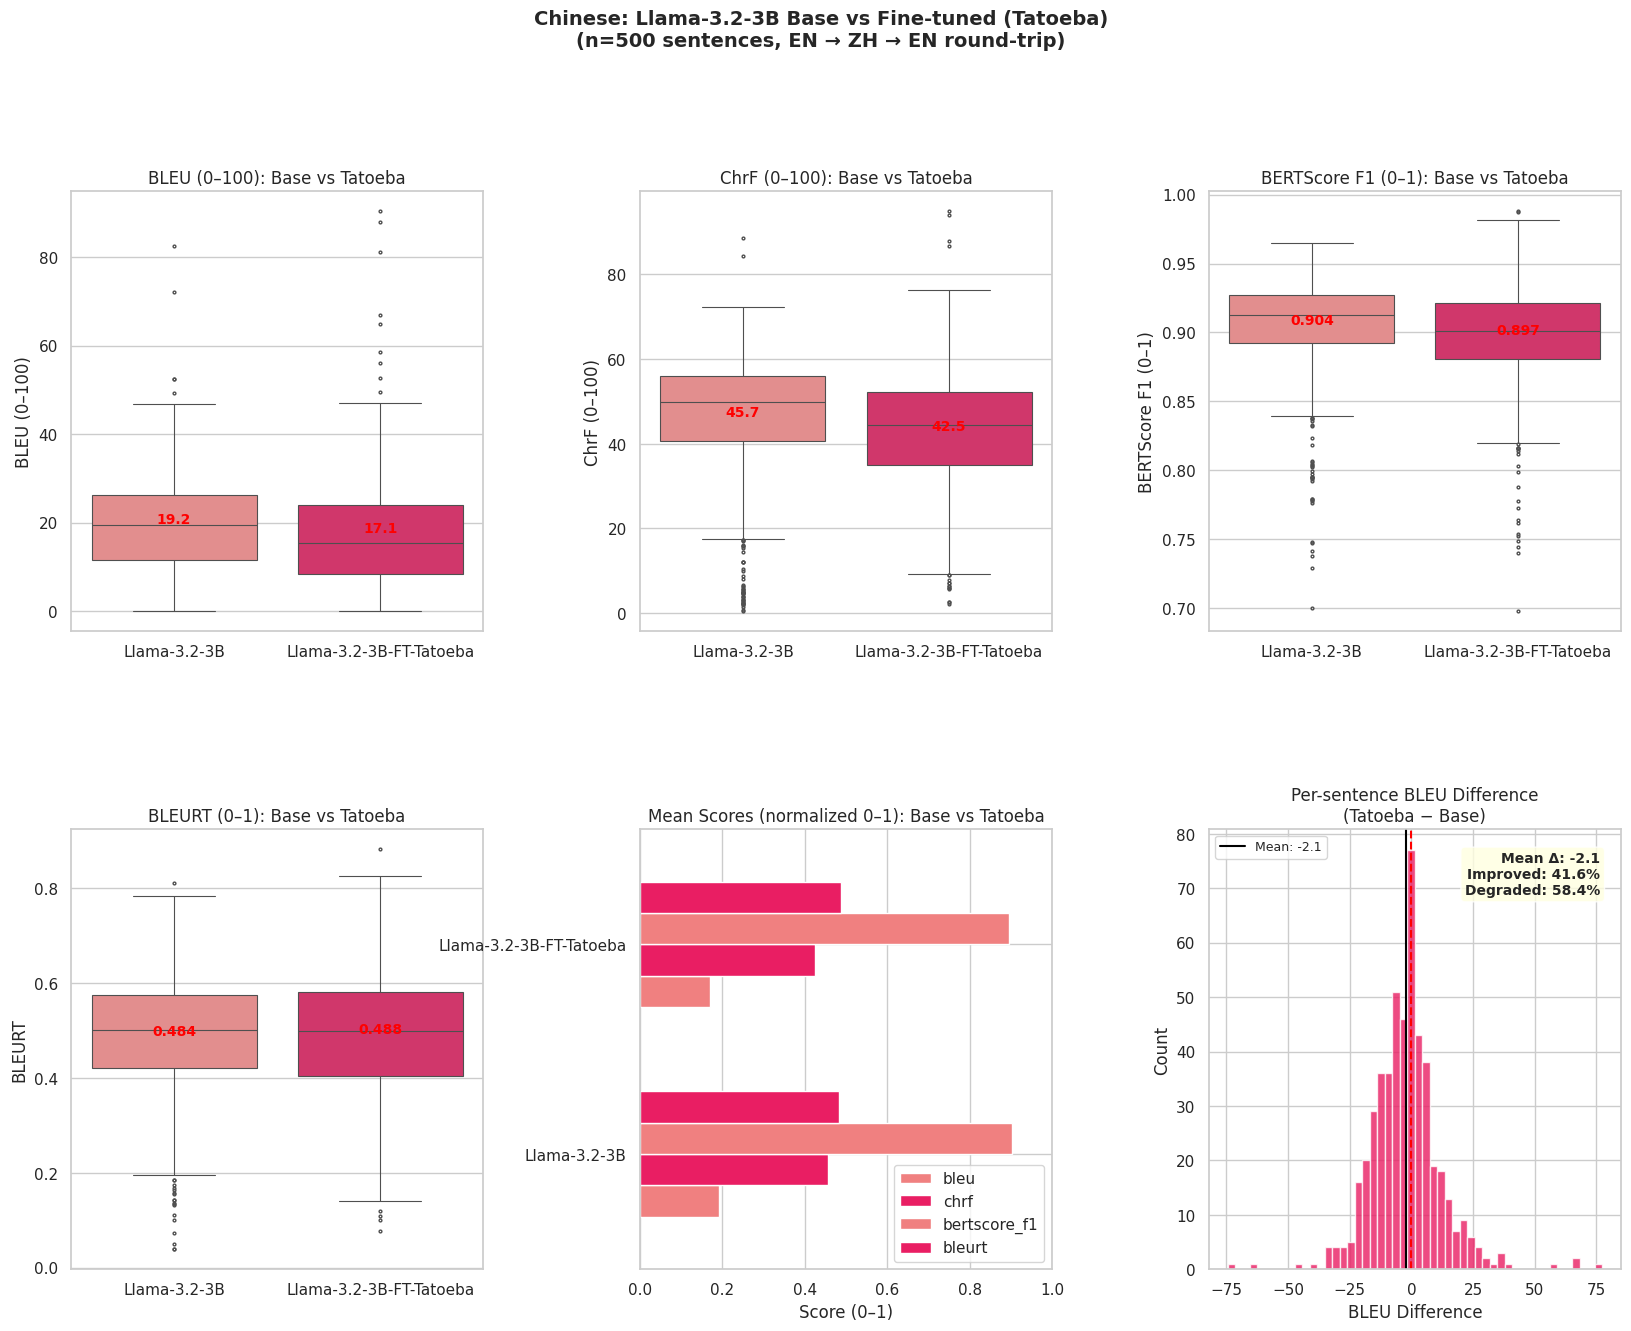

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Llama-32-3B-FT-Tatoeba_vs_base_dashboard.png



/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5703/3750297672.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


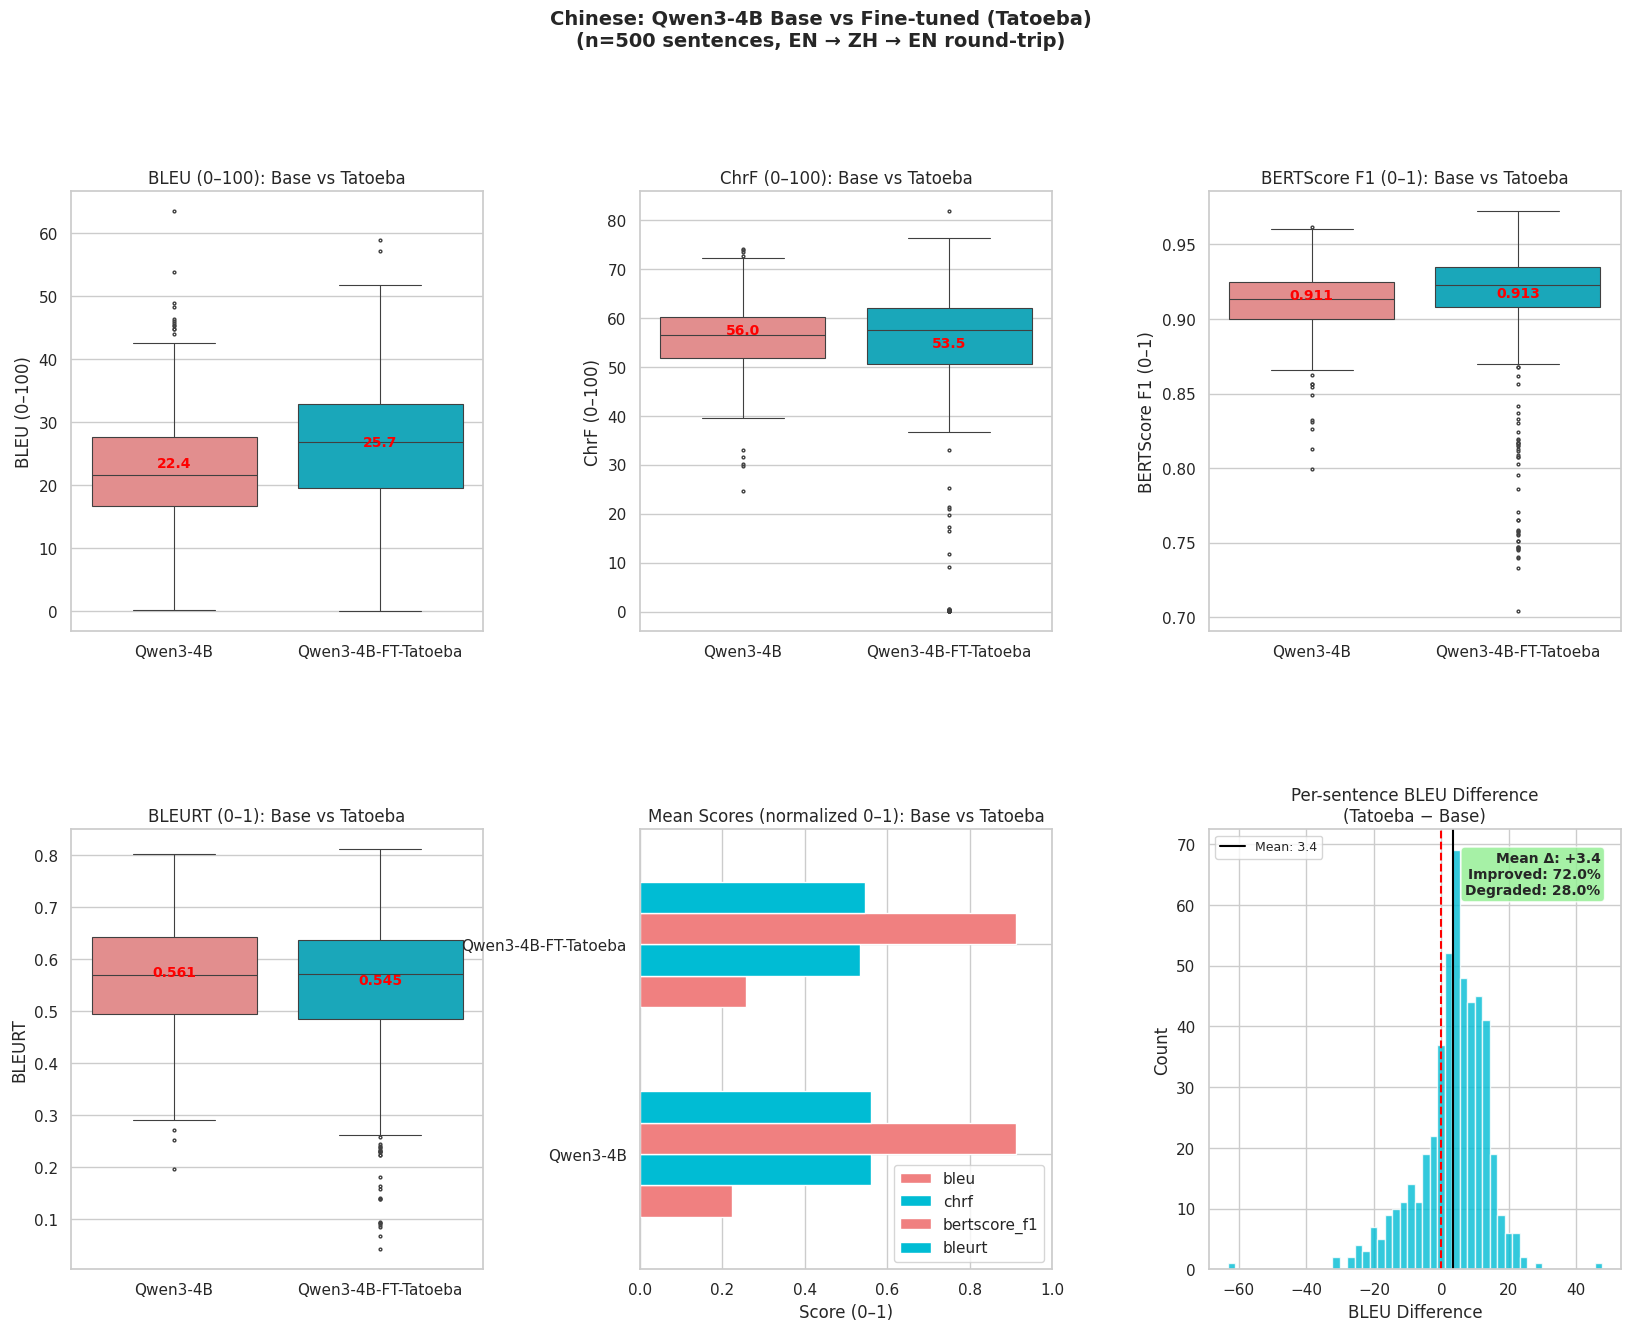

Saved to /content/drive/MyDrive/Coding project/evaluation_results/Qwen3-4B-FT-Tatoeba_vs_base_dashboard.png



In [37]:
chinese_df = df[df["language"] == "Chinese"].copy()

ft_pairs = [
    ("Llama-3.2-3B-FT-WMT",     "Llama-3.2-3B", "WMT"),
    ("Llama-3.2-3B-FT-Tatoeba", "Llama-3.2-3B", "Tatoeba"),
    ("Qwen3-4B-FT-Tatoeba",     "Qwen3-4B",     "Tatoeba"),
]

for ft_name, baseline_name, short_label in ft_pairs:
    if ft_name not in chinese_df["model"].unique() or baseline_name not in chinese_df["model"].unique():
        print(f"{ft_name} or {baseline_name} not found, skipping.")
        continue

    pair_df = chinese_df[chinese_df["model"].isin([baseline_name, ft_name])].copy()
    pair_order = [baseline_name, ft_name]
    pair_palette = {baseline_name: "lightcoral", ft_name: MODEL_COLORS[ft_name]}

    base_sorted = pair_df[pair_df["model"] == baseline_name].sort_values("english_original").reset_index(drop=True)
    ft_sorted = pair_df[pair_df["model"] == ft_name].sort_values("english_original").reset_index(drop=True)
    aligned = (
        len(base_sorted) == len(ft_sorted)
        and (base_sorted["english_original"].values == ft_sorted["english_original"].values).all()
    )

    fig = plt.figure(figsize=(20, 14))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    box_metrics = [
        ("bleu",         "BLEU (0–100)",       "steelblue"),
        ("chrf",         "ChrF (0–100)",        "darkorange"),
        ("bertscore_f1", "BERTScore F1 (0–1)",  "seagreen"),
    ]

    # Row 1: Paired box plots
    for col, (metric, label, _) in enumerate(box_metrics):
        ax = fig.add_subplot(gs[0, col])
        sns.boxplot(
            data=pair_df, x="model", y=metric,
            order=pair_order, palette=pair_palette,
            fliersize=2, linewidth=0.8, ax=ax,
        )
        means = pair_df.groupby("model")[metric].mean()
        fmt = ".1f" if metric != "bertscore_f1" else ".3f"
        for j, m in enumerate(pair_order):
            ax.text(j, means[m], f"{means[m]:{fmt}}",
                    ha="center", va="bottom", fontsize=10, color="red", fontweight="bold")
        ax.set_title(f"{label}: Base vs {short_label}")
        ax.set_xlabel("")
        ax.set_ylabel(label)

    # Row 2, col 0: BLEURT paired box plot
    ax_bl = fig.add_subplot(gs[1, 0])
    if HAS_BLEURT and pair_df["bleurt"].notna().any():
        sns.boxplot(
            data=pair_df, x="model", y="bleurt",
            order=pair_order, palette=pair_palette,
            fliersize=2, linewidth=0.8, ax=ax_bl,
        )
        means_bl = pair_df.groupby("model")["bleurt"].mean()
        for j, m in enumerate(pair_order):
            ax_bl.text(j, means_bl[m], f"{means_bl[m]:.3f}",
                       ha="center", va="bottom", fontsize=10, color="red", fontweight="bold")
        ax_bl.set_title(f"BLEURT (0–1): Base vs {short_label}")
        ax_bl.set_xlabel("")
        ax_bl.set_ylabel("BLEURT")
    else:
        ax_bl.text(0.5, 0.5, "BLEURT not available", transform=ax_bl.transAxes,
                   ha="center", va="center", fontsize=12, color="gray")
        ax_bl.set_axis_off()

    # Row 2, col 1: Normalized mean scores bar chart
    ax_bar = fig.add_subplot(gs[1, 1])
    bar_metrics = ["bleu", "chrf", "bertscore_f1"]
    bar_labels_list = ["BLEU", "ChrF", "BERTScore F1"]
    if HAS_BLEURT and pair_df["bleurt"].notna().any():
        bar_metrics.append("bleurt")
        bar_labels_list.append("BLEURT")
    means_compare = pair_df.groupby("model")[bar_metrics].mean().loc[pair_order]
    means_norm = means_compare.copy()
    means_norm["bleu"] = means_norm["bleu"] / 100
    means_norm["chrf"] = means_norm["chrf"] / 100
    means_norm.plot(kind="barh", ax=ax_bar,
                    color=["lightcoral", MODEL_COLORS[ft_name]],
                    width=0.6, edgecolor="white")
    ax_bar.set_title(f"Mean Scores (normalized 0–1): Base vs {short_label}")
    ax_bar.set_xlabel("Score (0–1)")
    ax_bar.set_ylabel("")
    ax_bar.legend(loc="lower right")
    ax_bar.set_xlim(0, 1)

    # Row 2, col 2: Per-sentence BLEU difference histogram
    ax_hist = fig.add_subplot(gs[1, 2])
    if aligned:
        diff_bleu = ft_sorted["bleu"].values - base_sorted["bleu"].values
        mean_diff = diff_bleu.mean()
        pct_improved = (diff_bleu > 0).mean() * 100
        pct_degraded = (diff_bleu < 0).mean() * 100

        ax_hist.hist(diff_bleu, bins=50, color=MODEL_COLORS[ft_name], edgecolor="white", alpha=0.8)
        ax_hist.axvline(0, color="red", linestyle="--", linewidth=1.5)
        ax_hist.axvline(mean_diff, color="black", linestyle="-", linewidth=1.5, label=f"Mean: {mean_diff:.1f}")
        ax_hist.set_title(f"Per-sentence BLEU Difference\n({short_label} − Base)")
        ax_hist.set_xlabel("BLEU Difference")
        ax_hist.set_ylabel("Count")

        summary_text = (
            f"Mean Δ: {mean_diff:+.1f}\n"
            f"Improved: {pct_improved:.1f}%\n"
            f"Degraded: {pct_degraded:.1f}%"
        )
        box_color = "lightgreen" if mean_diff > 0 else "lightyellow" if mean_diff > -5 else "#ffcccc"
        ax_hist.text(0.95, 0.95, summary_text,
                     transform=ax_hist.transAxes, ha="right", va="top",
                     fontsize=10, fontweight="bold",
                     bbox=dict(boxstyle="round,pad=0.3", facecolor=box_color, alpha=0.8))
        ax_hist.legend(fontsize=9)
    else:
        ax_hist.text(0.5, 0.5, "Sentences not aligned", transform=ax_hist.transAxes,
                     ha="center", va="center", fontsize=12, color="gray")
        ax_hist.set_axis_off()

    # Title includes the specific base model name
    n_sentences = len(base_sorted)
    plt.suptitle(
        f"Chinese: {baseline_name} Base vs Fine-tuned ({short_label})\n"
        f"(n={n_sentences} sentences, EN → ZH → EN round-trip)",
        fontsize=14, fontweight="bold", y=1.01,
    )
    safe = ft_name.replace(" ", "_").replace(".", "")
    path = os.path.join(OUTPUT_DIR, f"{safe}_vs_base_dashboard.png")
    plt.savefig(path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved to {path}\n")

In [38]:
print(f"\nAll evaluation results saved to: {OUTPUT_DIR}")
print("Files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"  {f} ({size_kb:.0f} KB)")


All evaluation results saved to: /content/drive/MyDrive/Coding project/evaluation_results/
Files:
  Claude-Haiku_dashboard.png (398 KB)
  Llama-32-3B-FT-Tatoeba_dashboard.png (243 KB)
  Llama-32-3B-FT-Tatoeba_vs_base_dashboard.png (231 KB)
  Llama-32-3B-FT-WMT_dashboard.png (251 KB)
  Llama-32-3B-FT-WMT_vs_base_dashboard.png (229 KB)
  Llama-32-3B-FT_dashboard.png (249 KB)
  Llama-32-3B_dashboard.png (471 KB)
  Llama-32-3B_filtered_dashboard.png (454 KB)
  Qwen3-4B-FT-Tatoeba_dashboard.png (240 KB)
  Qwen3-4B-FT-Tatoeba_vs_base_dashboard.png (235 KB)
  Qwen3-4B_dashboard.png (456 KB)
  all_results_scored.csv (33755 KB)
  chinese_radar.png (232 KB)
  cross_model_grouped_bars.png (245 KB)
  cross_model_violins.png (352 KB)
  finetuned_chinese_comparison.png (273 KB)
  summary_comparison.csv (2 KB)
